# Exploratory Data Analysis

Produces every EDA figure referenced in Chapter 4 (Methodology) and in Appendix A,
together with the LaTeX tables that accompany them.

**Inputs**

- `../data/raw/data.xlsx` — raw SCADA export
- `../data/processed/clean/*.csv` — sessions produced by `data_cleaning.ipynb`

**Outputs**

- figures into `../imgs/`
- LaTeX tables into `../tables/`, pulled into the thesis with `\input{}`

Run the cells in order. Every figure is both displayed inline and written to disk.

In [1]:
!pip install numpy pandas matplotlib openpyxl

## Setup

In [2]:
import os
import glob
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
RAW_PATH   = "../data/raw/data.xlsx"
RAW_SHEET  = "Sheet1"
CLEAN_DIR  = "../data/processed/clean"
IMG_DIR    = "../imgs"
TABLE_DIR  = "../tables"

DPI = 200

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

# ------------------------------------------------------------
# CONSTANTS — identical to the ones used in data_cleaning
# ------------------------------------------------------------
PT903_FROZEN_VALUE = -2.896296
PT903_FROZEN_ATOL  = 1e-4
FT801_SENTINEL     = -800.0

PRODUCTION_MODES = [8, 9]

FEATURES = [
    "PT-901", "PT-902", "PT-903",
    "TT-901", "TT-902", "TT-903", "TT-904",
    "FT-201", "FT-801", "FT-901",
    "VSD-901_CORRENT", "VSD-901_POWER", "VSD-901_RPM", "VSD-901_SPEED",
]

# Grouped so that variables sharing a unit and an order of magnitude are drawn
# on the same axes; VSD is kept apart because RPM is ~1000x the others
SENSOR_GROUPS = {
    "pressure":    ("Vacuum pressures",  ["PT-901", "PT-902", "PT-903"],           "Pressure (bar)"),
    "temperature": ("Temperatures",      ["TT-901", "TT-902", "TT-903", "TT-904"], r"Temperature ($^\circ$C)"),
    "flow":        ("Gas flows",         ["FT-201", "FT-801", "FT-901"],           r"Flow (Nm$^3$/h)"),
    "vsd":         ("Vacuum pump motor", ["VSD-901_CORRENT", "VSD-901_POWER",
                                          "VSD-901_RPM", "VSD-901_SPEED"],         "Value"),
}

UNITS = {
    "PT-901": "bar", "PT-902": "bar", "PT-903": "bar",
    "TT-901": "degC", "TT-902": "degC", "TT-903": "degC", "TT-904": "degC",
    "FT-201": "Nm3/h", "FT-801": "Nm3/h", "FT-901": "Nm3/h",
    "VSD-901_CORRENT": "A", "VSD-901_POWER": "W",
    "VSD-901_RPM": "RPM", "VSD-901_SPEED": "%",
}

print("Setup complete")

Setup complete


## Helpers

In [20]:
def tex(tag):
    """LaTeX-safe version of a sensor tag (underscores must be escaped)."""
    return tag.replace("_", r"\_")


def save(fig, name):
    """Write the figure to IMG_DIR and display it inline."""
    path = os.path.join(IMG_DIR, name)
    fig.savefig(path, dpi=DPI, bbox_inches="tight")
    print(f"wrote {path}")
    plt.show()


def save_table(body, name):
    path = os.path.join(TABLE_DIR, name)
    with open(path, "w") as fh:
        fh.write(body)
    print(f"wrote {path}")


def hist_values(series, exclude=None, min_value=None):
    """Return a plain float64 array suitable for matplotlib's hist().

    Passing a pandas Series directly to hist() raises a broadcasting error on
    recent pandas/numpy combinations (pandas 3.x with numpy 2.x), because
    np.histogram mishandles the backing extension array. Materialising the
    values as a contiguous float array and dropping any non-finite entries
    avoids the problem entirely.
    """
    v = np.asarray(series, dtype="float64")
    v = v[np.isfinite(v)]
    if exclude is not None:
        v = v[v != exclude]
    if min_value is not None:
        v = v[v > min_value]
    return v


def outlier_fraction(series):
    """Proportion of observations outside the 1.5 IQR fences."""
    s = series.dropna()
    if s.empty:
        return np.nan
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return 0.0
    mask = (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)
    return 100.0 * mask.sum() / len(s)


print("Helpers defined")

def moving_average(values, window):
    """Trailing moving average, equivalent to rolling(window, min_periods=1).mean().

    Computed with cumulative sums because pandas' own rolling().mean() returns
    all-NaN on this environment's pandas/numpy combination, silently and
    without raising.
    """
    v = np.asarray(values, dtype="float64")
    mask = np.isfinite(v)
    filled = np.where(mask, v, 0.0)
    csum = np.concatenate(([0.0], np.cumsum(filled)))
    ccnt = np.concatenate(([0.0], np.cumsum(mask.astype("float64"))))
    idx = np.arange(len(v)) + 1
    lo = np.maximum(idx - window, 0)
    total = csum[idx] - csum[lo]
    count = ccnt[idx] - ccnt[lo]
    with np.errstate(invalid="ignore"):
        return np.where(count > 0, total / np.maximum(count, 1.0), np.nan)

Helpers defined


## Loading the data

The raw export is trimmed at the first row where every sensor reports a valid reading,
exactly as `data_cleaning.ipynb` does, so the statistics below match the ones reported
in Chapter 4.

In [4]:
df_raw = pd.read_excel(RAW_PATH, sheet_name=RAW_SHEET)
df_raw["timestamp"] = pd.to_datetime(df_raw["timestamp"])
df_raw = df_raw.sort_values("timestamp").reset_index(drop=True)

n_before = len(df_raw)
first_complete_idx = df_raw.notna().all(axis=1).idxmax()
df_raw = df_raw.iloc[first_complete_idx:].reset_index(drop=True)

print(f"Raw observations           : {n_before:,}")
print(f"After trimming leading rows: {len(df_raw):,} (removed {n_before - len(df_raw):,})")

df_raw.head()

Raw observations           : 40,773
After trimming leading rows: 39,175 (removed 1,598)


,timestamp,FT-201,FT-801,FT-901,Mode,PT-901,PT-902,LS-901,PT-903,TT-901,TT-902,TT-903,TT-904,VSD-901_CORRENT,VSD-901_POWER,VSD-901_RPM,VSD-901_SPEED
0,2026-03-12 14:02:00,650.173645,306.323242,165.625000,8,-0.835576,0.006149,1.0,0.053356,76.052513,76.958549,87.608513,87.255859,44.460712,26.575775,1199.414062,99.986496
1,2026-03-12 14:03:00,636.892395,311.083984,560.677063,8,-0.465929,0.025825,1.0,0.158854,76.323784,77.354607,86.165367,86.181641,51.505035,31.616491,1198.461914,100.010574
2,2026-03-12 14:04:00,639.843750,312.207031,269.954437,8,-0.727937,0.010923,1.0,0.084664,76.470268,77.349174,86.078560,86.577690,48.174286,29.364229,1201.098633,100.013077
3,2026-03-12 14:05:00,648.046875,316.284180,172.884109,8,-0.821759,0.006655,1.0,0.057060,76.188148,77.115891,87.364365,87.147346,45.291733,26.933842,1200.512695,100.005547
4,2026-03-12 14:06:00,636.111145,319.873047,796.712280,9,-0.120732,0.047164,1.0,0.246296,75.678169,76.730690,86.838112,85.693359,50.286354,30.093130,1200.146484,100.080788


In [5]:
paths = sorted(
    glob.glob(os.path.join(CLEAN_DIR, "*.csv")),
    key=lambda p: int(os.path.basename(p).split("_")[2]),
)

sessions = {}
for path in paths:
    session_id = int(os.path.basename(path).split("_")[2])
    sessions[session_id] = pd.read_csv(path, index_col="timestamp", parse_dates=True)

print(f"Sessions loaded: {len(sessions)} "
      f"({sum(len(d) for d in sessions.values()):,} observations)")
for sid, d in sessions.items():
    print(f"  Session {sid:>2}: {len(d):>6,} rows  {d.index.min()} to {d.index.max()}")

Sessions loaded: 11 (37,376 observations)
  Session  1:  2,900 rows  2026-03-12 15:38:00 to 2026-03-14 15:57:00
  Session  2:  1,799 rows  2026-03-14 22:50:00 to 2026-03-16 04:48:00
  Session  3:  4,763 rows  2026-03-16 09:02:00 to 2026-03-19 16:24:00
  Session  5:  1,606 rows  2026-03-20 03:25:00 to 2026-03-21 06:10:00
  Session  8:  1,235 rows  2026-03-21 18:10:00 to 2026-03-22 14:44:00
  Session 12:  2,556 rows  2026-03-23 14:22:00 to 2026-03-25 08:57:00
  Session 13:  8,938 rows  2026-03-25 09:31:00 to 2026-03-31 14:28:00
  Session 14:  2,527 rows  2026-03-31 15:00:00 to 2026-04-02 09:06:00
  Session 15:  3,270 rows  2026-04-02 10:28:00 to 2026-04-04 16:57:00
  Session 16:  3,367 rows  2026-04-04 19:45:00 to 2026-04-07 03:51:00
  Session 17:  4,415 rows  2026-04-07 07:42:00 to 2026-04-10 09:16:00


# Chapter 4 figures and tables

## Descriptive statistics

Feeds `Table~\ref{tab:eda_summary}`.

In [6]:
rows = []
for tag in FEATURES:
    s = df_raw[tag].dropna()
    rows.append({
        "tag": tag,
        "mean": s.mean(), "std": s.std(), "min": s.min(),
        "q1": s.quantile(0.25), "median": s.median(), "q3": s.quantile(0.75),
        "max": s.max(), "outliers": outlier_fraction(s),
    })
stats = pd.DataFrame(rows)

lines = [
    r"% Auto-generated by eda.ipynb -- do not edit by hand",
    r"\begin{tabular}{lrrrrrrrr}",
    r"\hline",
    r"\textbf{Tag} & \textbf{Mean} & \textbf{Std} & \textbf{Min} & \textbf{Q1} & "
    r"\textbf{Median} & \textbf{Q3} & \textbf{Max} & \textbf{Outliers (\%)} \\",
    r"\hline",
]
for _, r in stats.iterrows():
    d = 3 if r["tag"].startswith("PT") else 2   # pressures need more decimals
    lines.append(
        f"{tex(r['tag']):<16} & {r['mean']:.{d}f} & {r['std']:.{d}f} & {r['min']:.{d}f} & "
        f"{r['q1']:.{d}f} & {r['median']:.{d}f} & {r['q3']:.{d}f} & {r['max']:.{d}f} & "
        f"{r['outliers']:.2f} \\\\"
    )
lines += [r"\hline", r"\end{tabular}"]
save_table("\n".join(lines) + "\n", "eda_summary.tex")

stats.round(3)

wrote ../tables/eda_summary.tex


,tag,mean,std,min,q1,median,q3,max,outliers
0,PT-901,-0.681,0.249,-1.025,-0.833,-0.721,-0.552,0.088,3.689
1,PT-902,0.014,0.012,-0.014,0.006,0.011,0.020,0.051,3.380
2,PT-903,0.066,0.265,-2.896,0.050,0.081,0.126,0.259,1.340
3,TT-901,67.058,5.049,18.392,64.708,67.486,69.954,77.083,1.478
4,TT-902,68.252,4.956,19.119,65.951,68.631,71.094,78.114,1.419
5,TT-903,77.239,5.235,21.425,74.631,77.696,80.184,88.395,1.401
6,TT-904,77.013,5.493,18.365,74.571,77.469,79.937,87.918,1.585
7,FT-201,621.789,160.074,-15.061,597.092,652.127,718.815,826.259,9.955
8,FT-801,308.181,87.328,-800.000,303.589,328.638,352.563,760.181,7.885
9,FT-901,307.040,235.334,2.246,159.294,266.699,434.977,929.004,3.579


## Timestamp gaps

Feeds `Table~\ref{tab:eda_gaps}` and `Figure~\ref{fig:eda_gaps_overview}`.

In [7]:
diffs = df_raw["timestamp"].diff()
gaps = df_raw.loc[diffs > pd.Timedelta(minutes=1)].copy()
gaps["gap"] = diffs[diffs > pd.Timedelta(minutes=1)]

bins = [
    ("1--5 min",    pd.Timedelta(minutes=1),  pd.Timedelta(minutes=5)),
    ("5--30 min",   pd.Timedelta(minutes=5),  pd.Timedelta(minutes=30)),
    ("30 min--2 h", pd.Timedelta(minutes=30), pd.Timedelta(hours=2)),
    ("2--12 h",     pd.Timedelta(hours=2),    pd.Timedelta(hours=12)),
    (r"$>$12 h",    pd.Timedelta(hours=12),   pd.Timedelta(days=365)),
]

lines = [
    r"% Auto-generated by eda.ipynb -- do not edit by hand",
    r"\begin{tabular}{lr}",
    r"\hline",
    r"\textbf{Gap duration} & \textbf{Count} \\",
    r"\hline",
]
for label, lo, hi in bins:
    n = int(((gaps["gap"] > lo) & (gaps["gap"] <= hi)).sum())
    print(f"{label:<14} {n:>4}")
    lines.append(f"{label} & {n} \\\\")
lines += [
    r"\hline",
    rf"\textbf{{Total}} & \textbf{{{len(gaps)}}} \\",
    r"\hline",
    r"\end{tabular}",
]
save_table("\n".join(lines) + "\n", "eda_gaps.tex")

print(f"\n{len(gaps)} gaps > 1 min, totalling {gaps['gap'].sum()}")

1--5 min         33
5--30 min        37
30 min--2 h       3
2--12 h           4
$>$12 h           0
wrote ../tables/eda_gaps.tex

77 gaps > 1 min, totalling 1 days 16:03:01.430000


wrote ../imgs/eda_gaps_overview.png


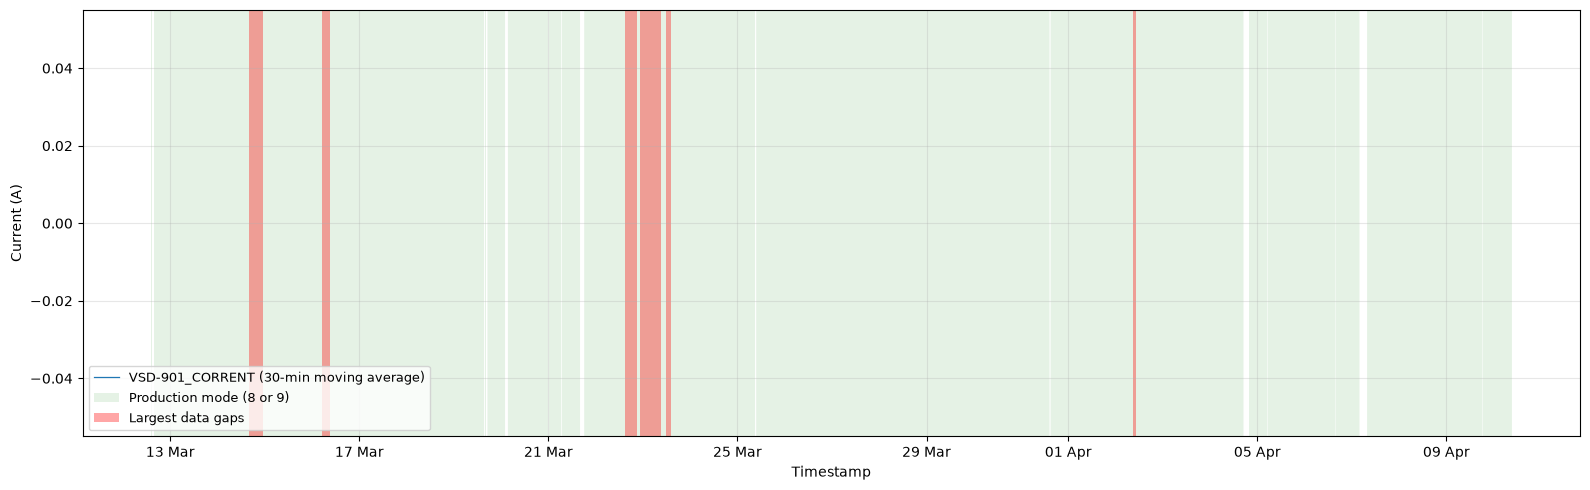

In [22]:
N_LARGEST = 7
largest = gaps.nlargest(N_LARGEST, "gap")

fig, ax = plt.subplots(figsize=(16, 5))

current = df_raw.set_index("timestamp")["VSD-901_CORRENT"].rolling(30, min_periods=1).mean()
ax.plot(current.index, current.values, color="#1f77b4", linewidth=0.9,
        label="VSD-901_CORRENT (30-min moving average)")

in_prod = df_raw["Mode"].isin(PRODUCTION_MODES).to_numpy()
ax.fill_between(df_raw["timestamp"], 0, 1, where=in_prod,
                transform=ax.get_xaxis_transform(),
                color="green", alpha=0.10, linewidth=0,
                label="Production mode (8 or 9)")

for i, (_, row) in enumerate(largest.iterrows()):
    gap_end   = row["timestamp"]
    gap_start = gap_end - row["gap"]
    ax.axvspan(gap_start, gap_end, color="red", alpha=0.35, linewidth=0,
               label="Largest data gaps" if i == 0 else None)

ax.set_ylabel("Current (A)")
ax.set_xlabel("Timestamp")
ax.legend(loc="lower left", fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
fig.tight_layout()
save(fig, "eda_gaps_overview.png")

## PT-901 VPSA cycle and pressure distributions

Feeds `Figure~\ref{fig:eda_pt901_cycle}`. Adjust `EXCERPT_HOURS` if the switching
between adsorption columns is not clearly legible in the top panel.

wrote ../imgs/eda_pt901_cycle_and_distributions.png


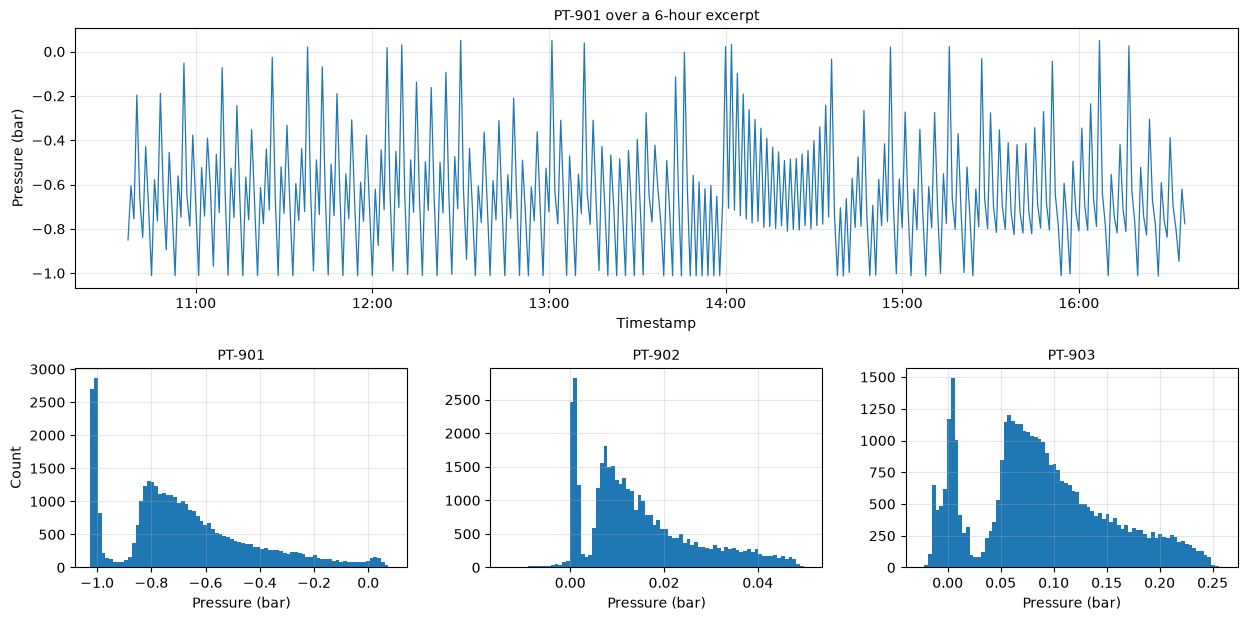

In [10]:
EXCERPT_HOURS = 6

prod = df_raw[df_raw["Mode"].isin(PRODUCTION_MODES)]

# excerpt taken from the middle of the production data
mid = prod["timestamp"].iloc[len(prod) // 2]
window = prod[(prod["timestamp"] >= mid) &
              (prod["timestamp"] < mid + pd.Timedelta(hours=EXCERPT_HOURS))]

fig = plt.figure(figsize=(15, 7))
gs = fig.add_gridspec(2, 3, height_ratios=[1.3, 1.0], hspace=0.35, wspace=0.25)

ax_top = fig.add_subplot(gs[0, :])
ax_top.plot(window["timestamp"], window["PT-901"], color="#1f77b4", linewidth=0.9)
ax_top.set_ylabel("Pressure (bar)")
ax_top.set_xlabel("Timestamp")
ax_top.set_title(f"PT-901 over a {EXCERPT_HOURS}-hour excerpt", fontsize=10)
ax_top.grid(True, alpha=0.3)
ax_top.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

for col, tag in enumerate(["PT-901", "PT-902", "PT-903"]):
    ax = fig.add_subplot(gs[1, col])
    # PT-903 has the frozen sentinel far from the bulk; clip the view so the
    # shape of the actual distribution stays readable
    data = hist_values(prod[tag],
                       min_value=PT903_FROZEN_VALUE + 1.0 if tag == "PT-903" else None)
    # Explicit bin edges: an integer bin count sends numpy down its
    # bincount-based fast path, which miscounts on numpy 2.5 and raises a
    # broadcasting error. An array of edges uses the searchsorted path instead.
    edges = np.linspace(data.min(), data.max(), 81)
    ax.hist(data, bins=edges, color="#1f77b4", edgecolor="none")
    ax.set_title(tag, fontsize=10)
    ax.set_xlabel("Pressure (bar)")
    if col == 0:
        ax.set_ylabel("Count")
    ax.grid(True, alpha=0.3)

save(fig, "eda_pt901_cycle_and_distributions.png")

## Frozen PT-903 episode

Feeds `Figure~\ref{fig:eda_pt903_frozen}`.

294 frozen observations, 2026-04-07 04:11:00 to 2026-04-07 09:09:00
wrote ../imgs/eda_pt903_frozen.png


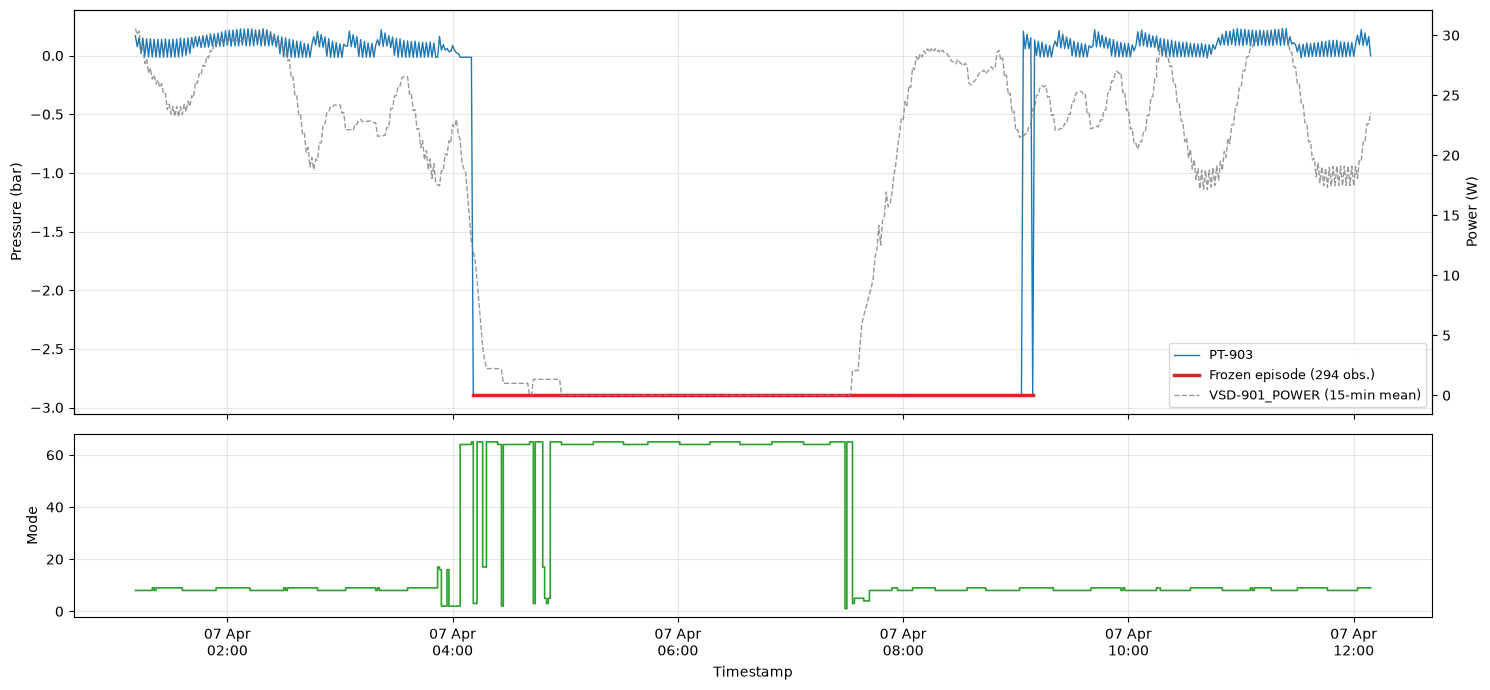

In [11]:
PAD_HOURS = 3

frozen = np.isclose(df_raw["PT-903"], PT903_FROZEN_VALUE, atol=PT903_FROZEN_ATOL)
n_frozen = int(frozen.sum())

t_start = df_raw.loc[frozen, "timestamp"].min()
t_end   = df_raw.loc[frozen, "timestamp"].max()
print(f"{n_frozen} frozen observations, {t_start} to {t_end}")

view = df_raw[(df_raw["timestamp"] >= t_start - pd.Timedelta(hours=PAD_HOURS)) &
              (df_raw["timestamp"] <= t_end + pd.Timedelta(hours=PAD_HOURS))].copy()
view_frozen = np.isclose(view["PT-903"], PT903_FROZEN_VALUE, atol=PT903_FROZEN_ATOL)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7), sharex=True,
                               gridspec_kw={"height_ratios": [2.2, 1.0]})

ax1.plot(view["timestamp"], view["PT-903"], color="#1f77b4", linewidth=1.0, label="PT-903")
ax1.plot(view.loc[view_frozen, "timestamp"], view.loc[view_frozen, "PT-903"],
         color="#d62728", linewidth=2.5, label=f"Frozen episode ({n_frozen} obs.)")
ax1.set_ylabel("Pressure (bar)")
ax1.grid(True, alpha=0.3)

ax1b = ax1.twinx()
power = view["VSD-901_POWER"].rolling(15, min_periods=1).mean()
ax1b.plot(view["timestamp"], power, color="gray", linewidth=1.0,
          linestyle="--", alpha=0.8, label="VSD-901_POWER (15-min mean)")
ax1b.set_ylabel("Power (W)")

handles = ax1.get_legend_handles_labels()[0] + ax1b.get_legend_handles_labels()[0]
labels  = ax1.get_legend_handles_labels()[1] + ax1b.get_legend_handles_labels()[1]
ax1.legend(handles, labels, loc="lower right", fontsize=9)

ax2.step(view["timestamp"], view["Mode"], where="post", color="#2ca02c", linewidth=1.2)
ax2.set_ylabel("Mode")
ax2.set_xlabel("Timestamp")
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M"))

fig.tight_layout()
save(fig, "eda_pt903_frozen.png")

## Correlation matrix

Feeds `Figure~\ref{fig:eda_correlation}` and `Table~\ref{tab:ap1_correlation}`.

Restricted to production modes. The frozen PT-903 episode and the FT-801 sentinel
readings are excluded: a constant reading carries no variance and would distort every
coefficient involving the affected variable.

Rows used for the correlation: 38,201
wrote ../imgs/eda_correlation_matrix.png


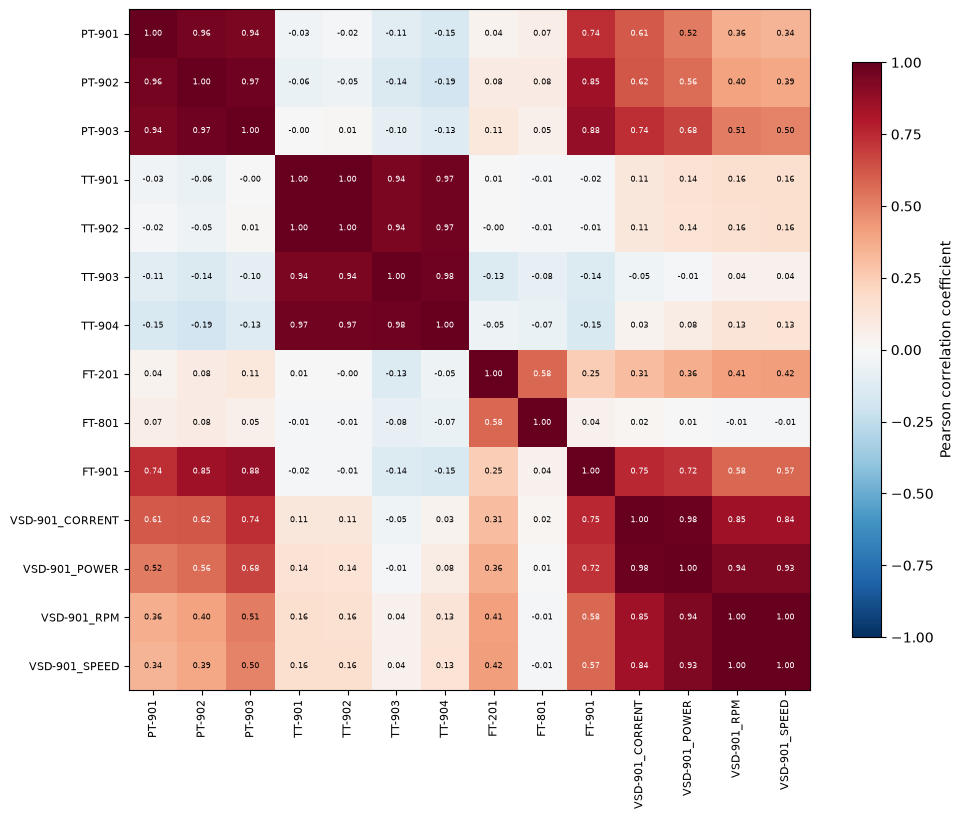

wrote ../tables/eda_correlation_values.tex


In [12]:
prod = df_raw[df_raw["Mode"].isin(PRODUCTION_MODES)].copy()
frozen_mask = np.isclose(prod["PT-903"], PT903_FROZEN_VALUE, atol=PT903_FROZEN_ATOL)
prod = prod.loc[~frozen_mask]
prod = prod.loc[prod["FT-801"] != FT801_SENTINEL]
print(f"Rows used for the correlation: {len(prod):,}")

corr = prod[FEATURES].corr(method="pearson")

fig, ax = plt.subplots(figsize=(10, 8.5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(FEATURES)))
ax.set_yticks(range(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=90, fontsize=8)
ax.set_yticklabels(FEATURES, fontsize=8)

for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6,
                color="white" if abs(v) > 0.55 else "black")

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Pearson correlation coefficient")
fig.tight_layout()
save(fig, "eda_correlation_matrix.png")

# numeric version for the appendix
lines = [
    r"% Auto-generated by eda.ipynb -- do not edit by hand",
    r"\begin{tabular}{l" + "r" * len(FEATURES) + "}",
    r"\hline",
    " & " + " & ".join(rf"\rotatebox{{90}}{{{tex(t)}}}" for t in FEATURES) + r" \\",
    r"\hline",
]
for tag in FEATURES:
    vals = " & ".join(f"{corr.loc[tag, other]:.2f}" for other in FEATURES)
    lines.append(f"{tex(tag)} & {vals} \\\\")
lines += [r"\hline", r"\end{tabular}"]
save_table("\n".join(lines) + "\n", "eda_correlation_values.tex")

# Appendix A figures and tables

## Time series over the full collection period

Feeds `Figures~\ref{fig:ap1_ts_pressure}` to `\ref{fig:ap1_ts_vsd}`. Plotted without
filtering by operating mode, so the non-production periods stay visible.

wrote ../imgs/eda_appendix_timeseries_pressure.png


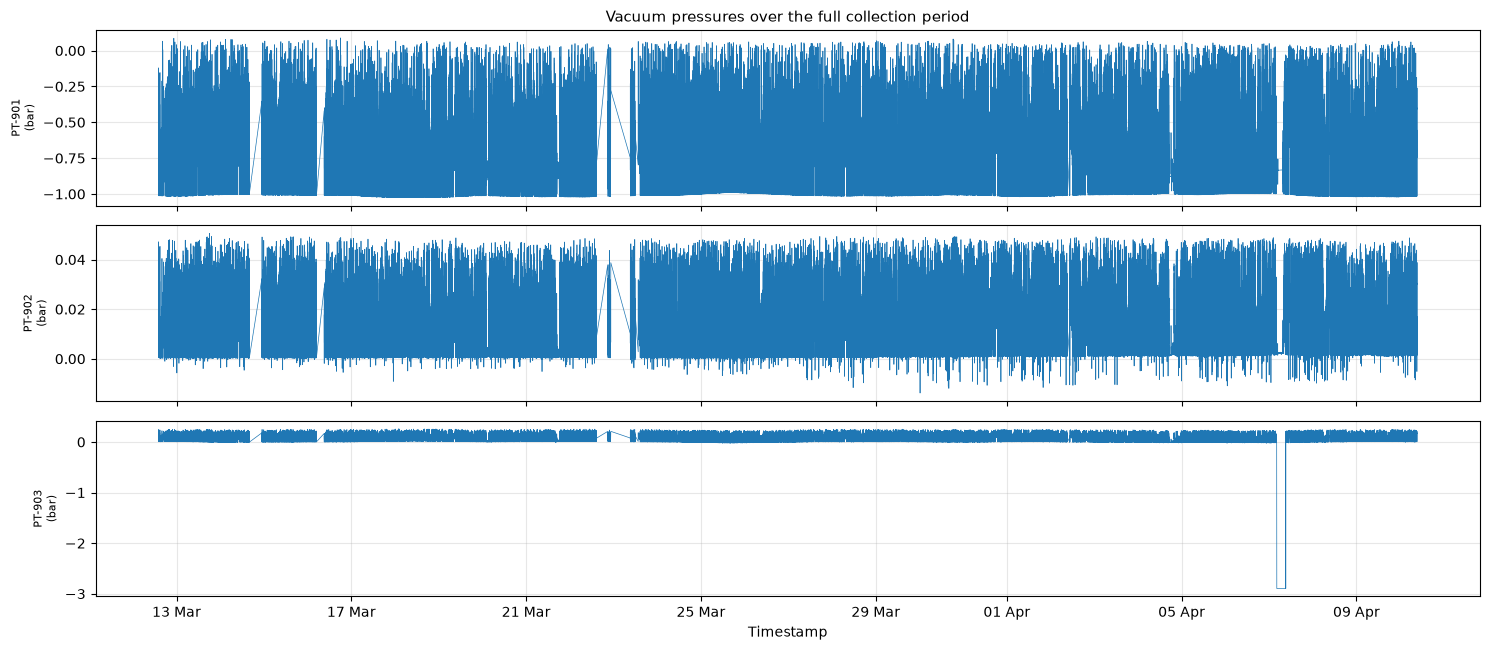

wrote ../imgs/eda_appendix_timeseries_temperature.png


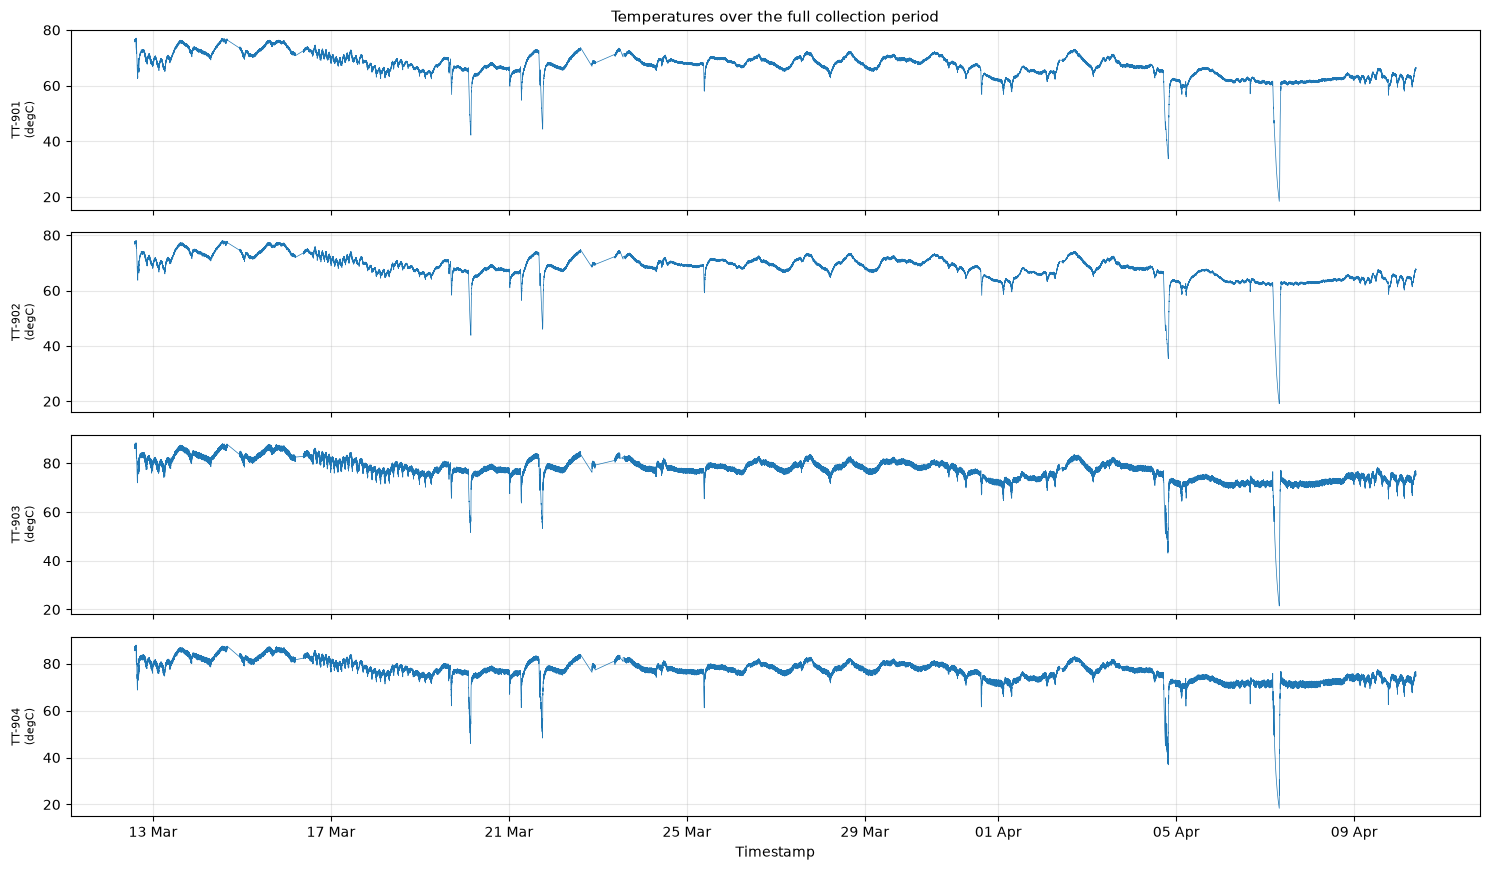

wrote ../imgs/eda_appendix_timeseries_flow.png


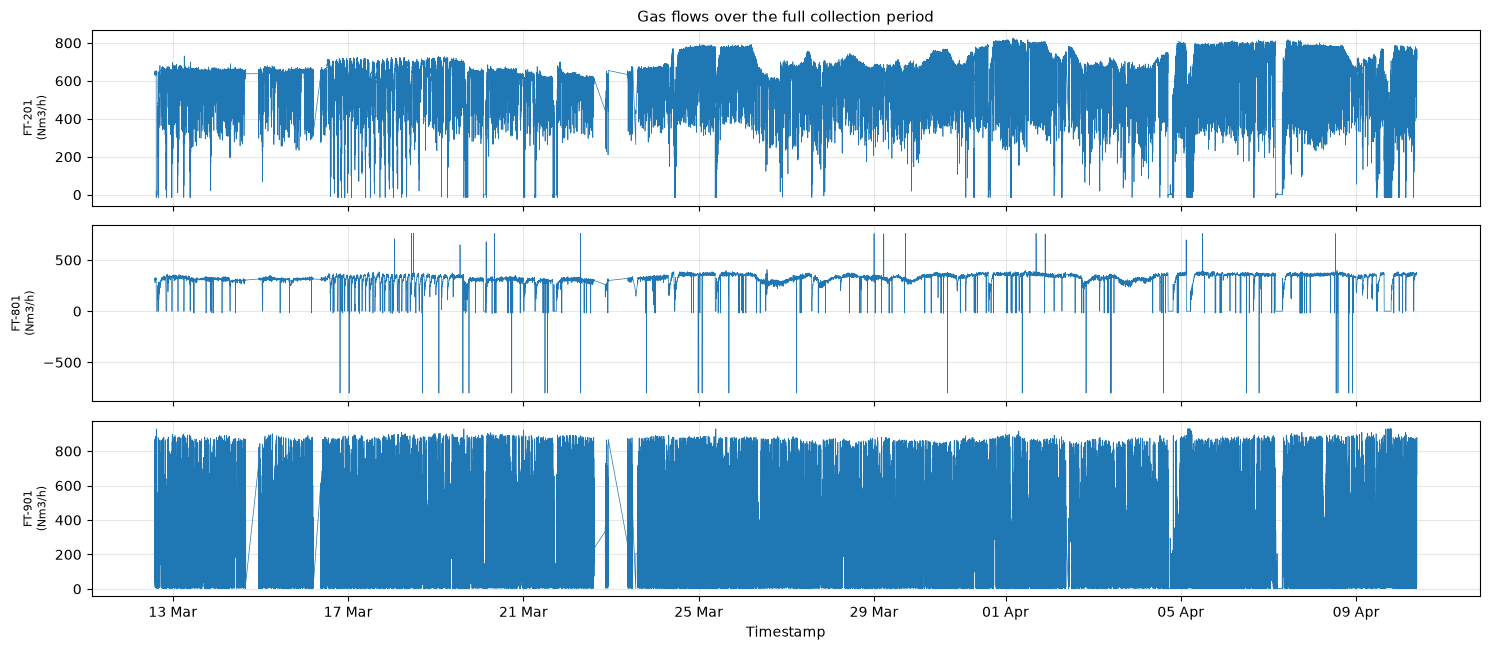

wrote ../imgs/eda_appendix_timeseries_vsd.png


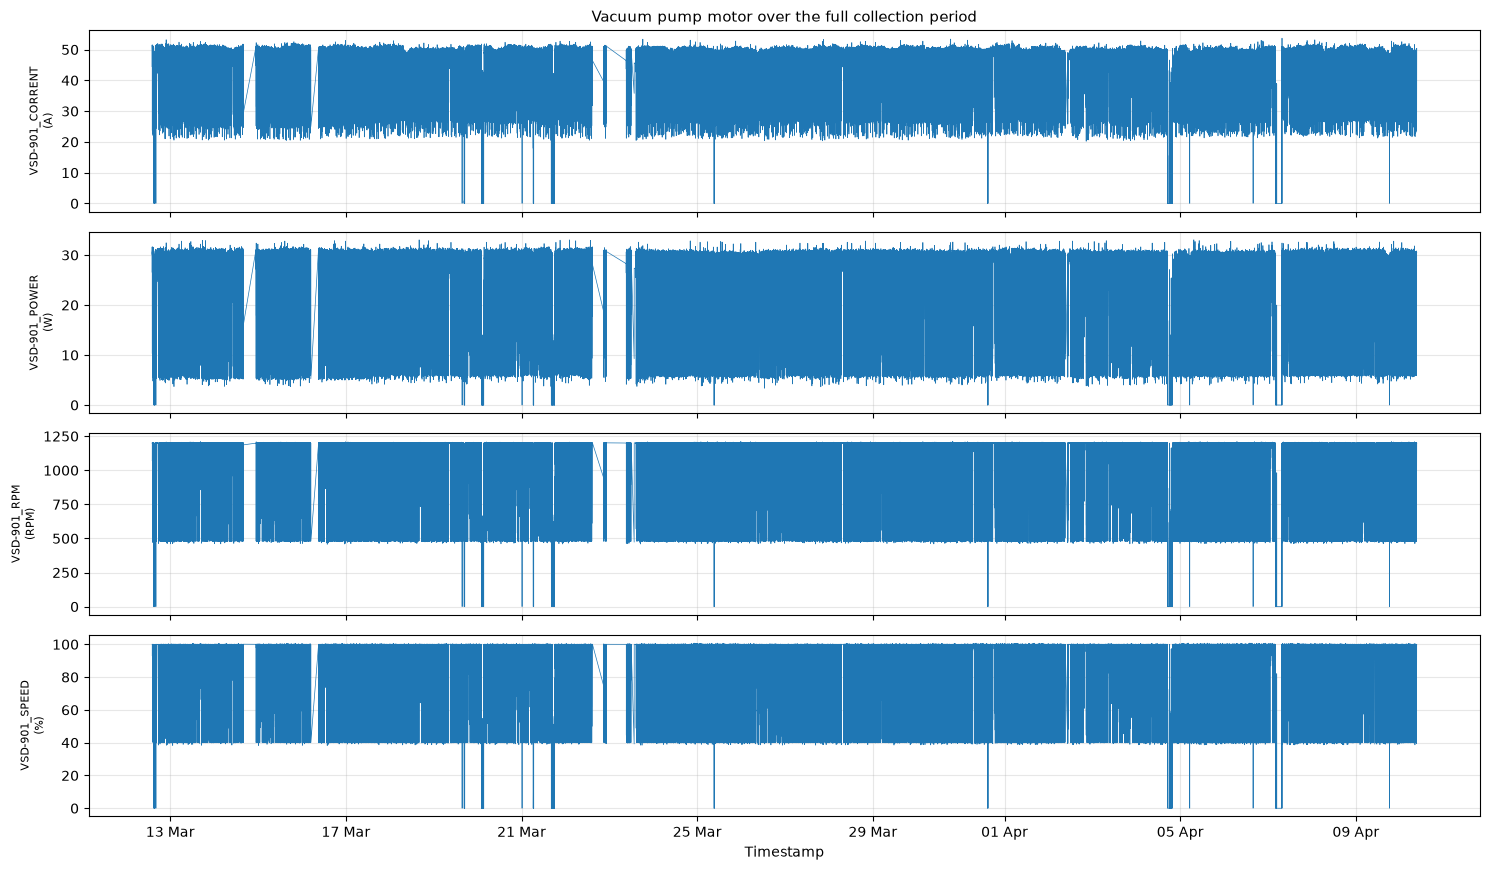

In [13]:
for key, (title, tags, ylabel) in SENSOR_GROUPS.items():
    n = len(tags)
    fig, axes = plt.subplots(n, 1, figsize=(15, 2.2 * n), sharex=True)
    axes = np.atleast_1d(axes)

    for ax, tag in zip(axes, tags):
        ax.plot(df_raw["timestamp"], df_raw[tag], linewidth=0.5, color="#1f77b4")
        ax.set_ylabel(f"{tag}\n({UNITS[tag]})", fontsize=8)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Timestamp")
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    axes[0].set_title(f"{title} over the full collection period", fontsize=11)
    fig.tight_layout()
    save(fig, f"eda_appendix_timeseries_{key}.png")

## Distributions of the continuous process variables

Feeds `Figure~\ref{fig:ap1_distributions}`. The frozen PT-903 readings and the FT-801
sentinels are excluded so they do not compress the rest of each distribution into a
single bin.

wrote ../imgs/eda_appendix_distributions.png


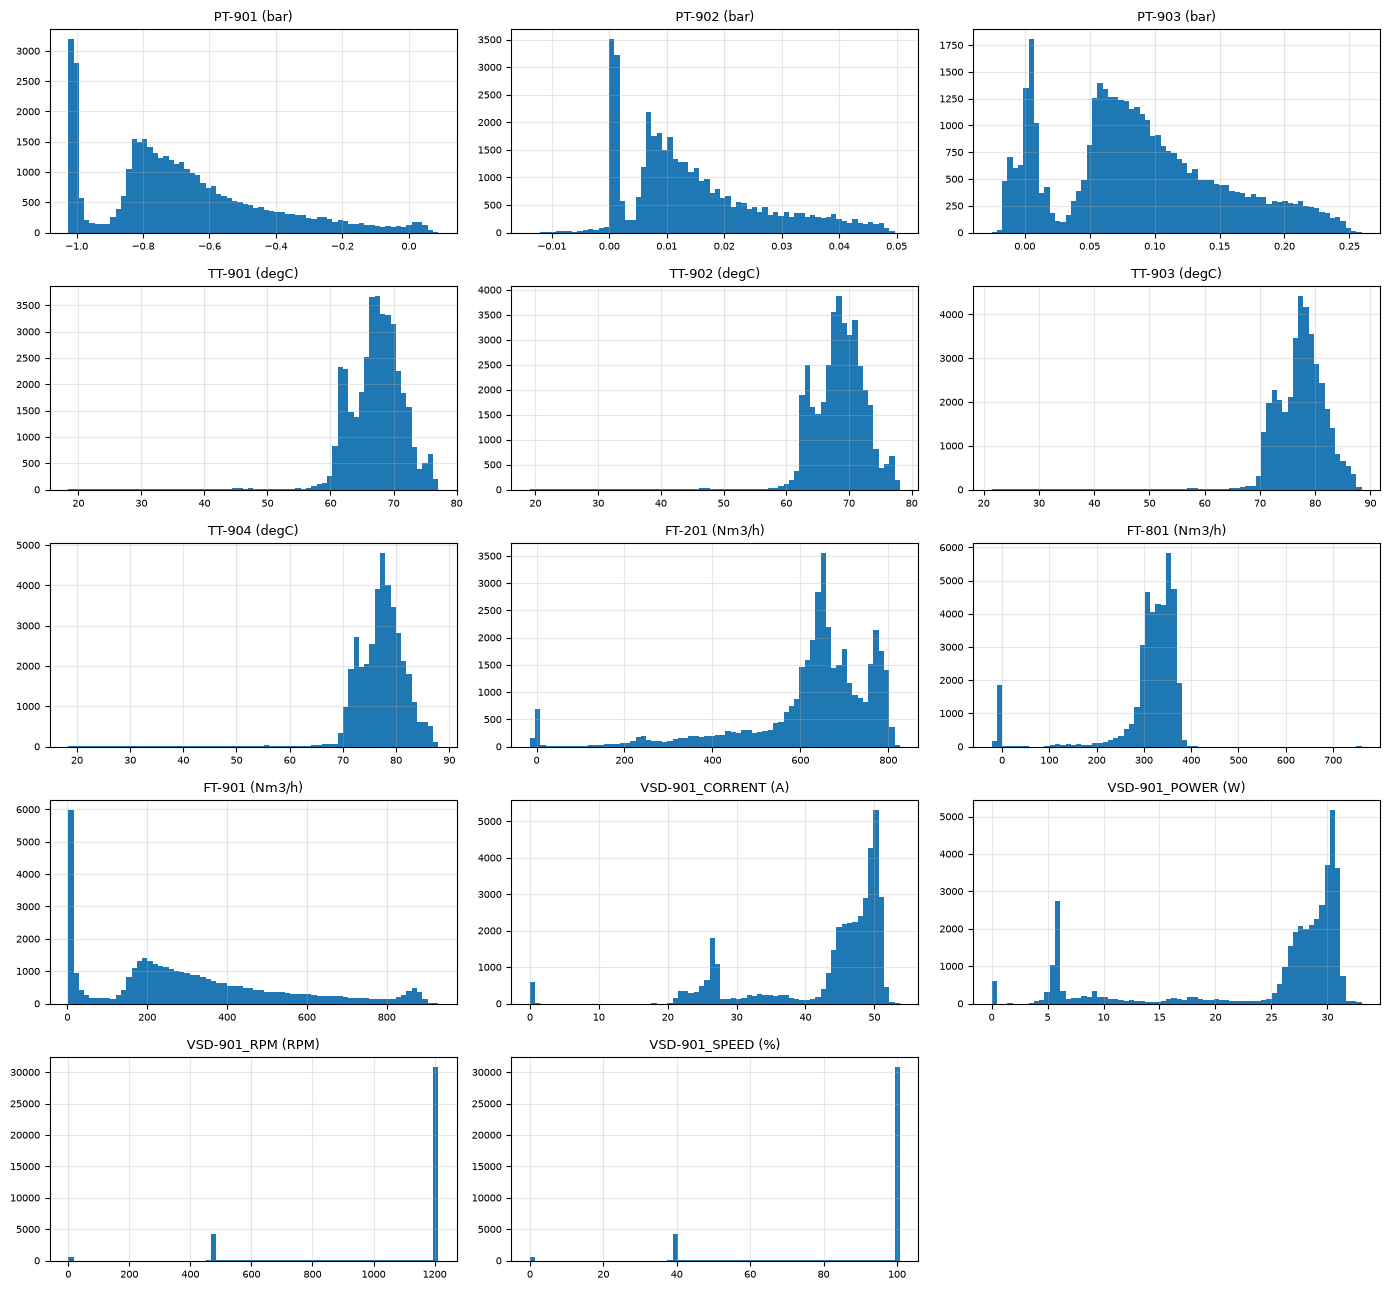

In [14]:
n_cols = 3
n_rows = int(np.ceil(len(FEATURES) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 2.6 * n_rows))
axes = axes.ravel()

for ax, tag in zip(axes, FEATURES):
    data = hist_values(
        df_raw[tag],
        exclude=FT801_SENTINEL if tag == "FT-801" else None,
        min_value=PT903_FROZEN_VALUE + 1.0 if tag == "PT-903" else None,
    )
    edges = np.linspace(data.min(), data.max(), 71)
    ax.hist(data, bins=edges, color="#1f77b4", edgecolor="none")
    ax.set_title(f"{tag} ({UNITS[tag]})", fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=7)

for ax in axes[len(FEATURES):]:
    ax.axis("off")

fig.tight_layout()
save(fig, "eda_appendix_distributions.png")

## Production session overviews

Feeds `Figures~\ref{fig:ap1_session_1}` to `\ref{fig:ap1_session_17}`. These use the
cleaned data: production modes only, resampled to one minute, short gaps interpolated.

wrote ../imgs/eda_appendix_session_1.png


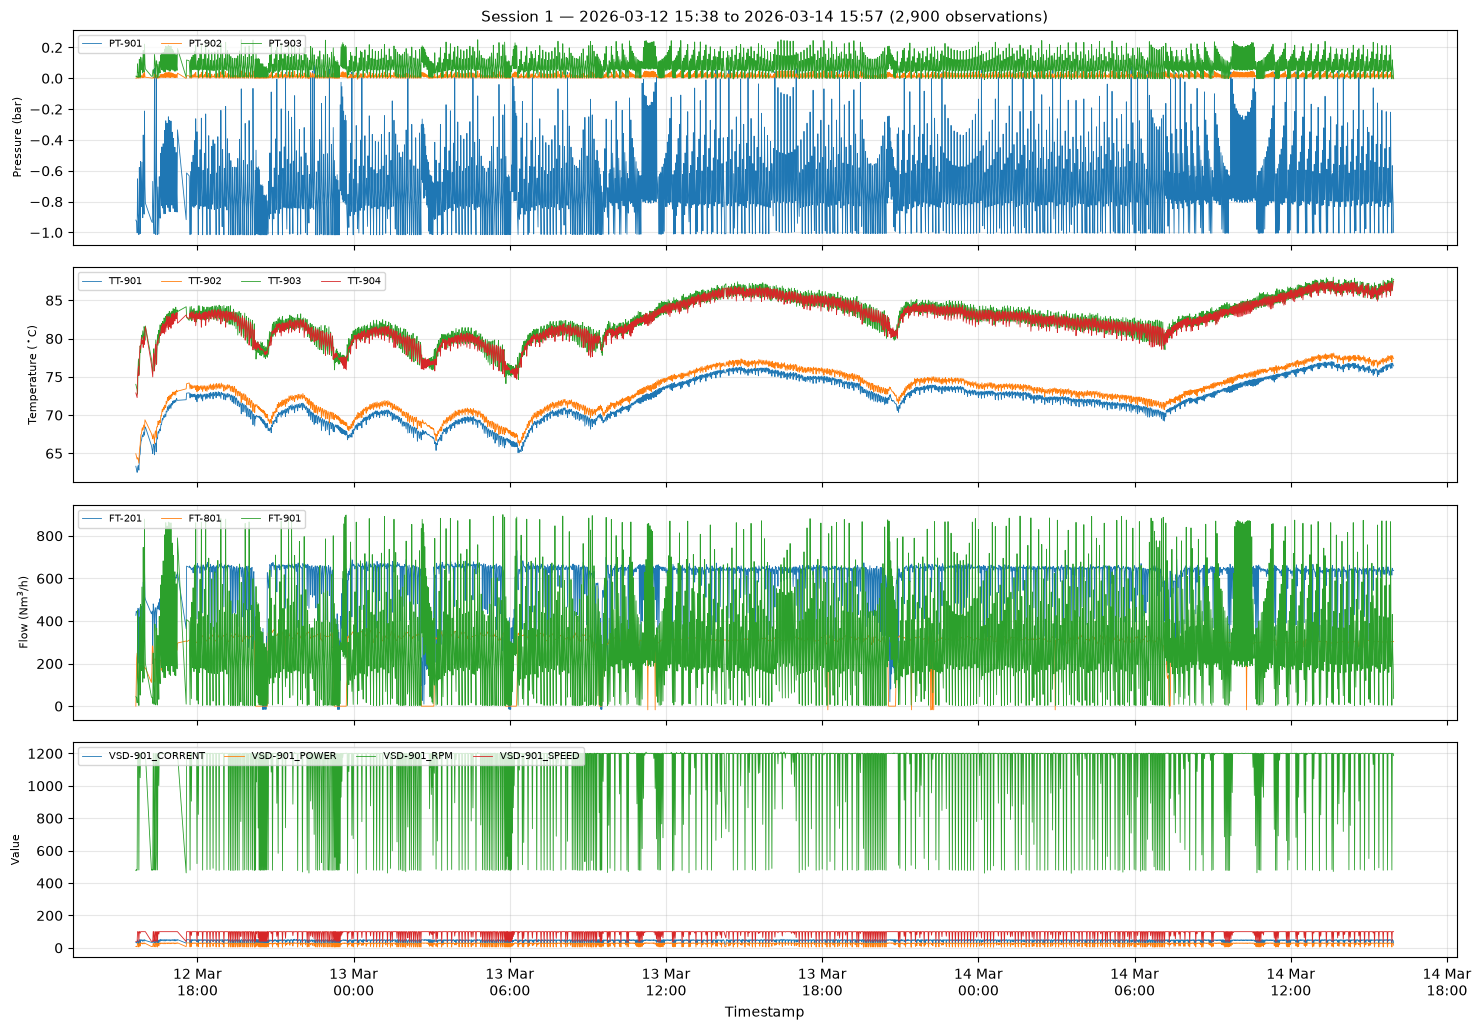

wrote ../imgs/eda_appendix_session_2.png


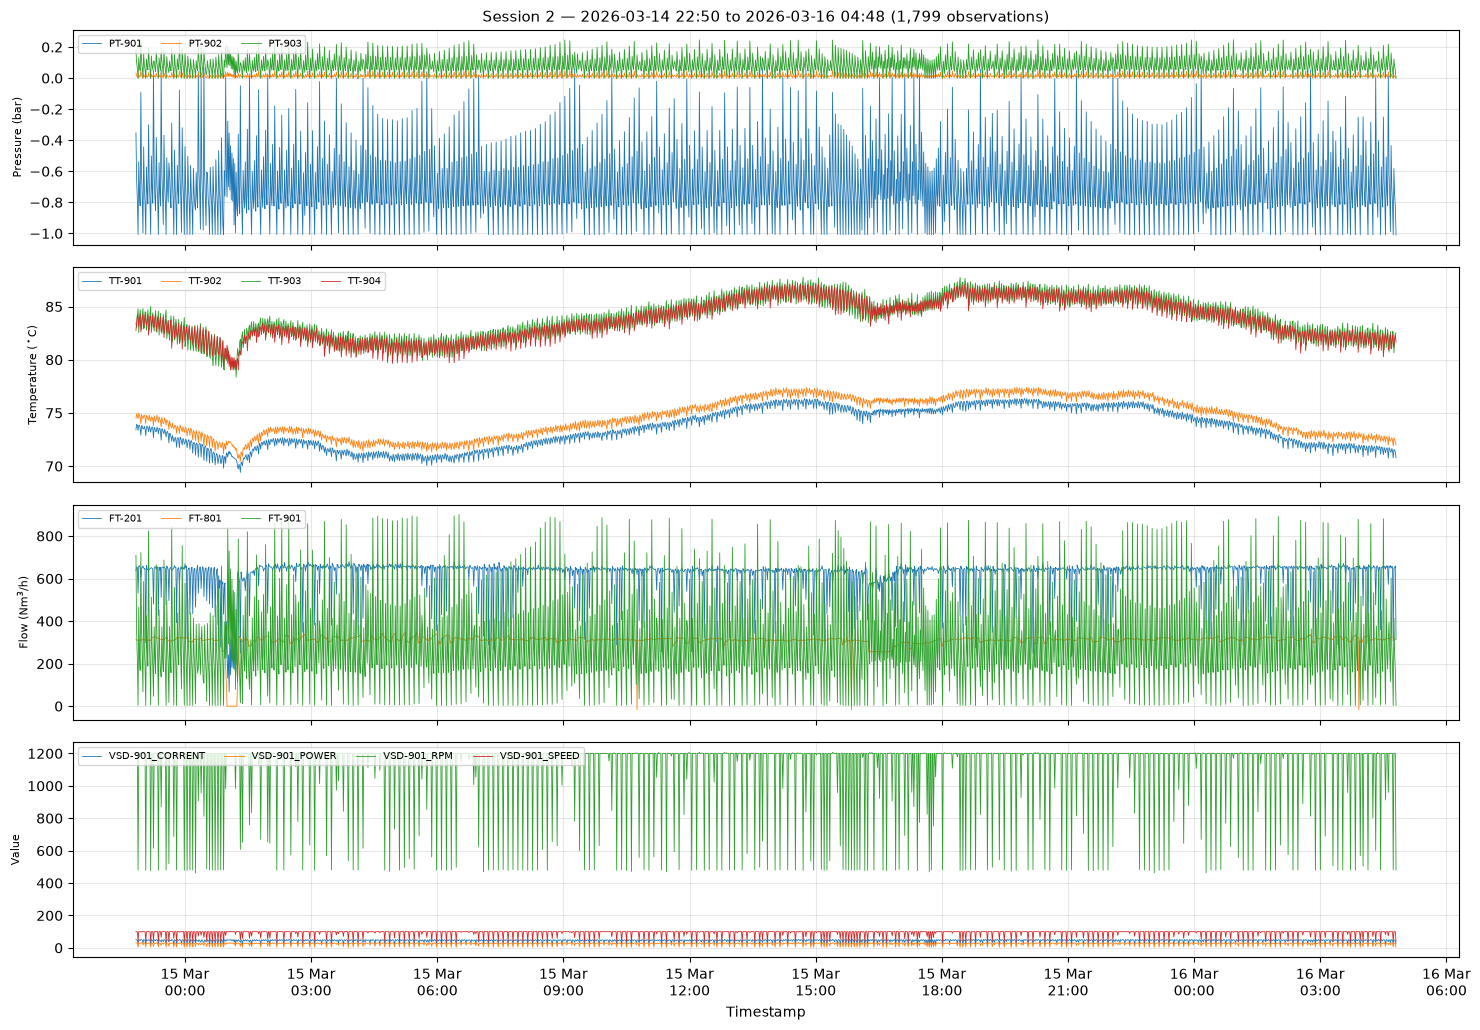

wrote ../imgs/eda_appendix_session_3.png


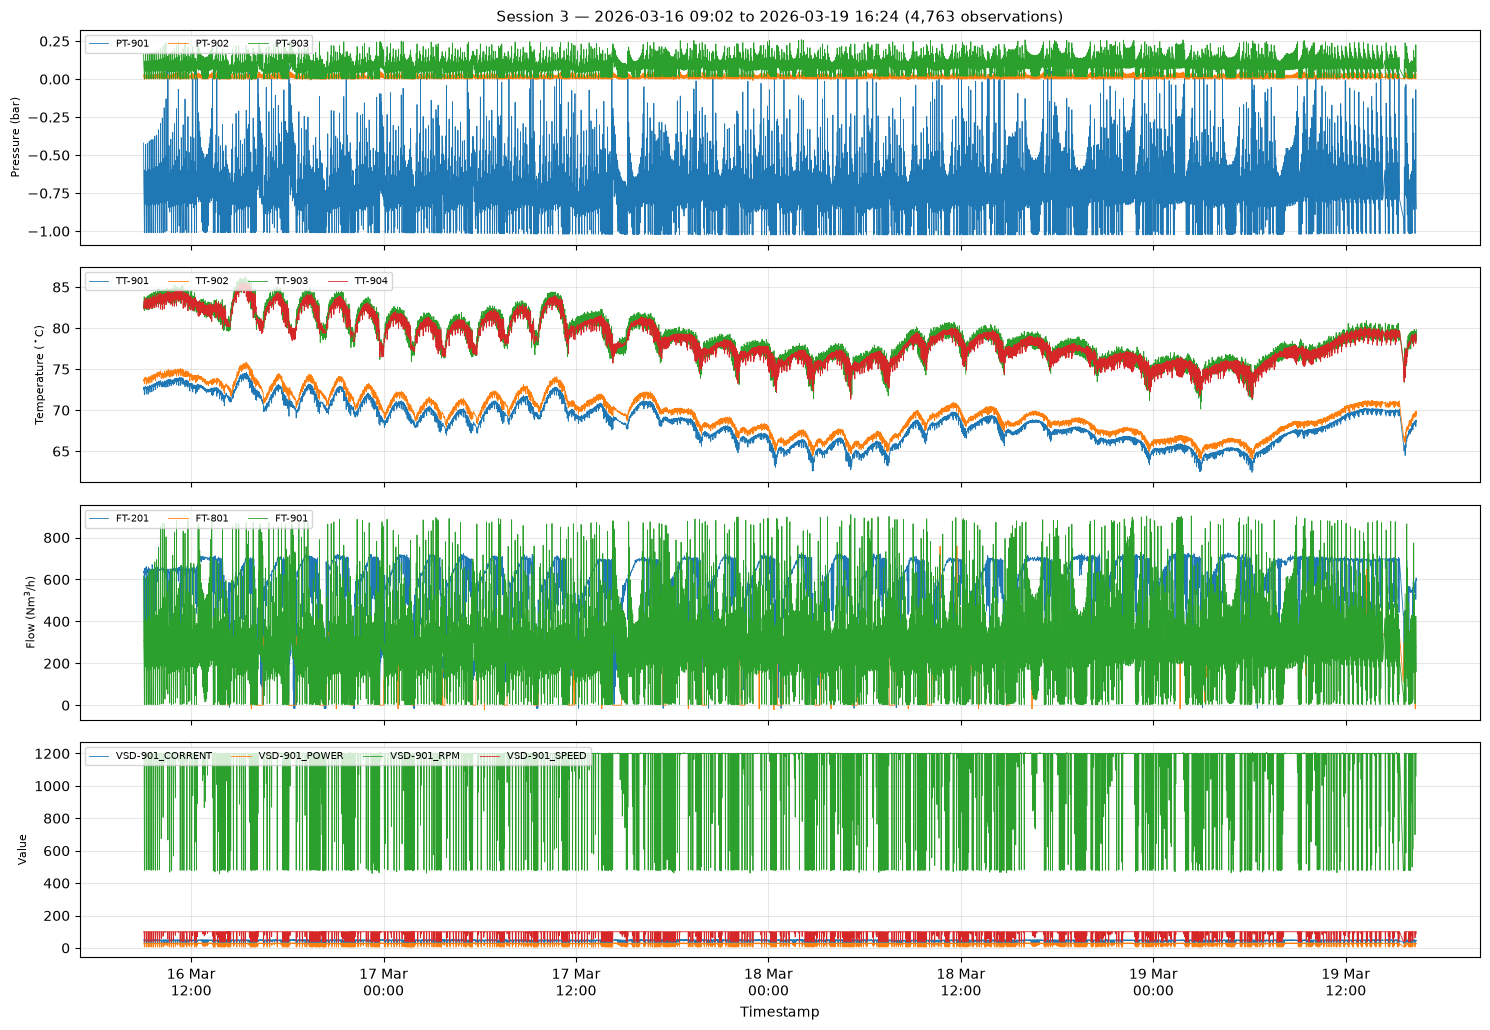

wrote ../imgs/eda_appendix_session_5.png


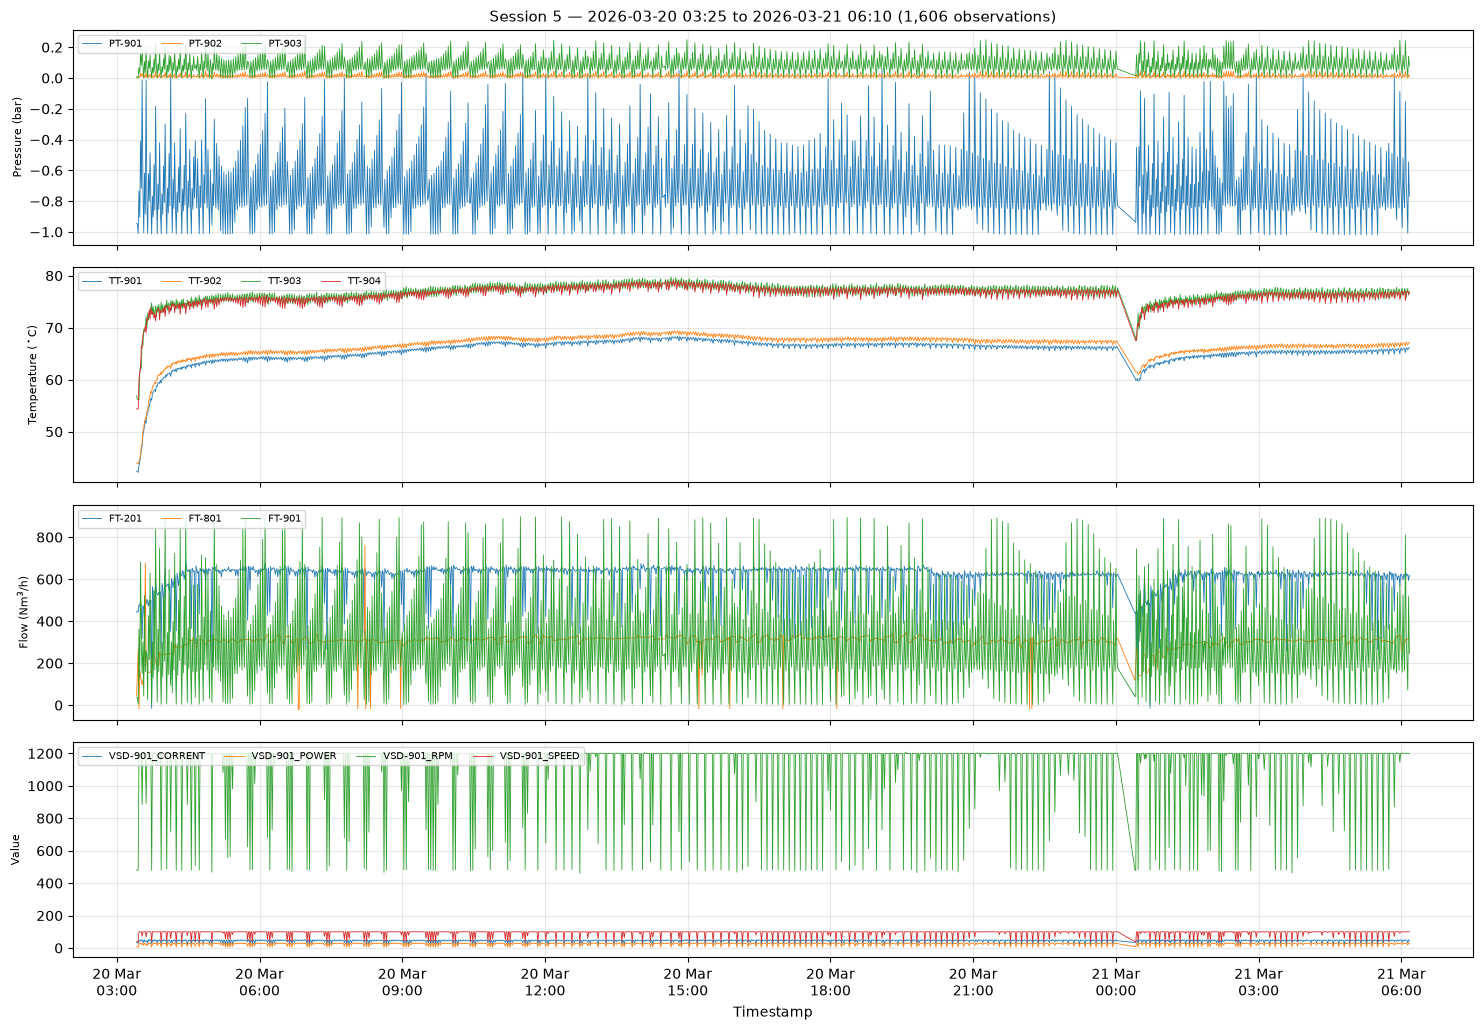

wrote ../imgs/eda_appendix_session_8.png


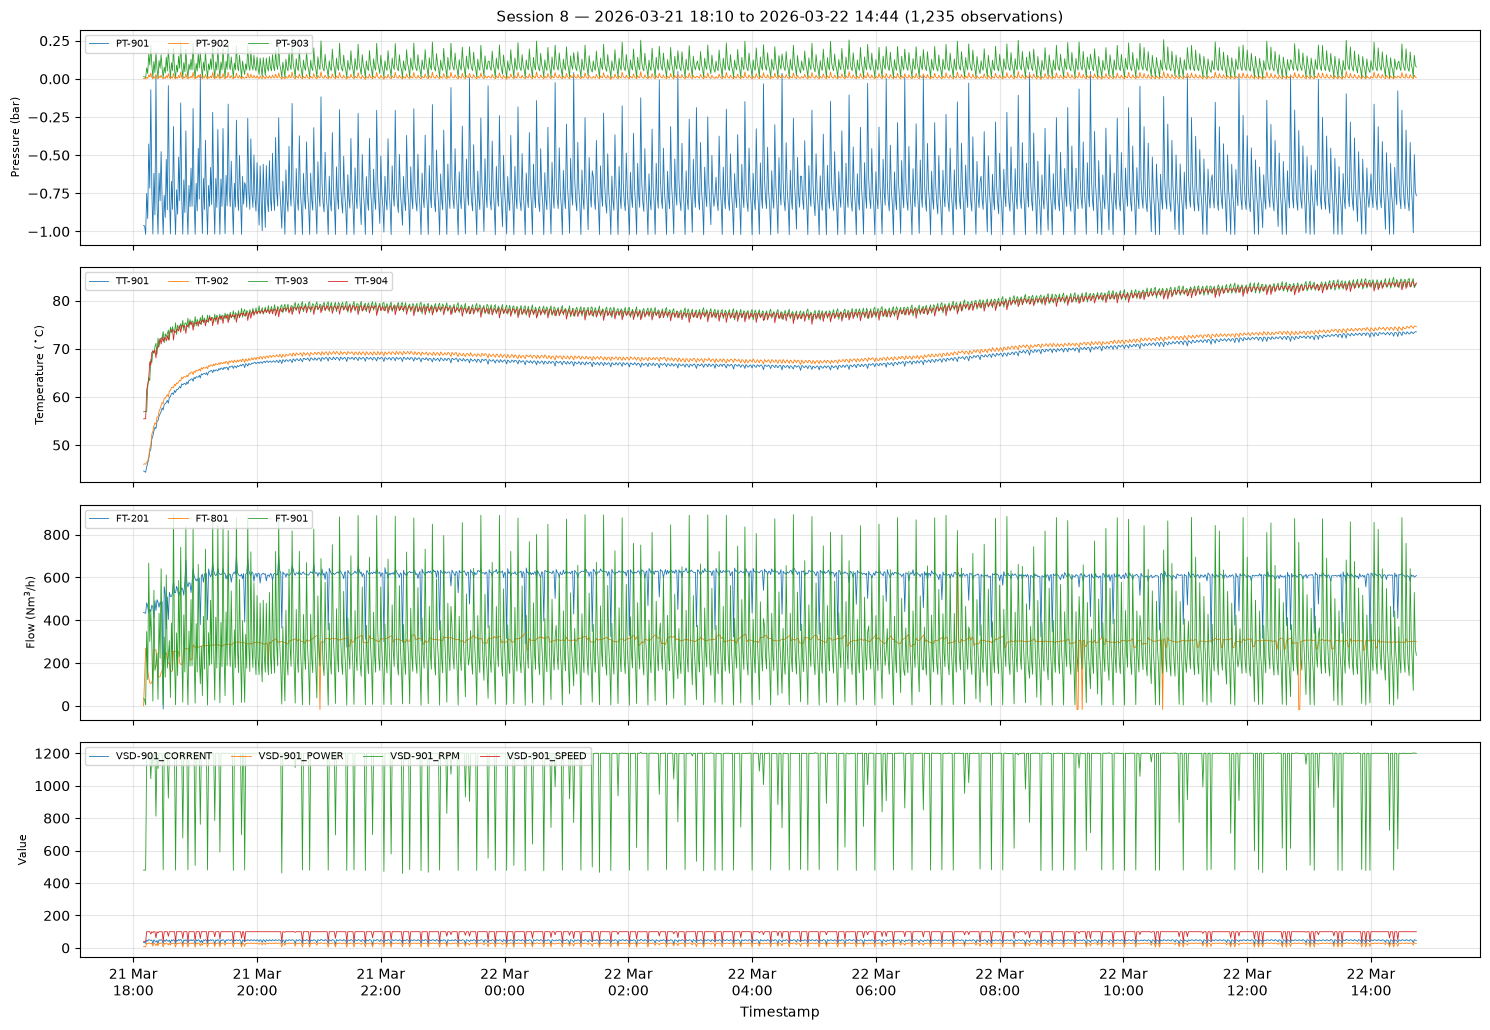

wrote ../imgs/eda_appendix_session_12.png


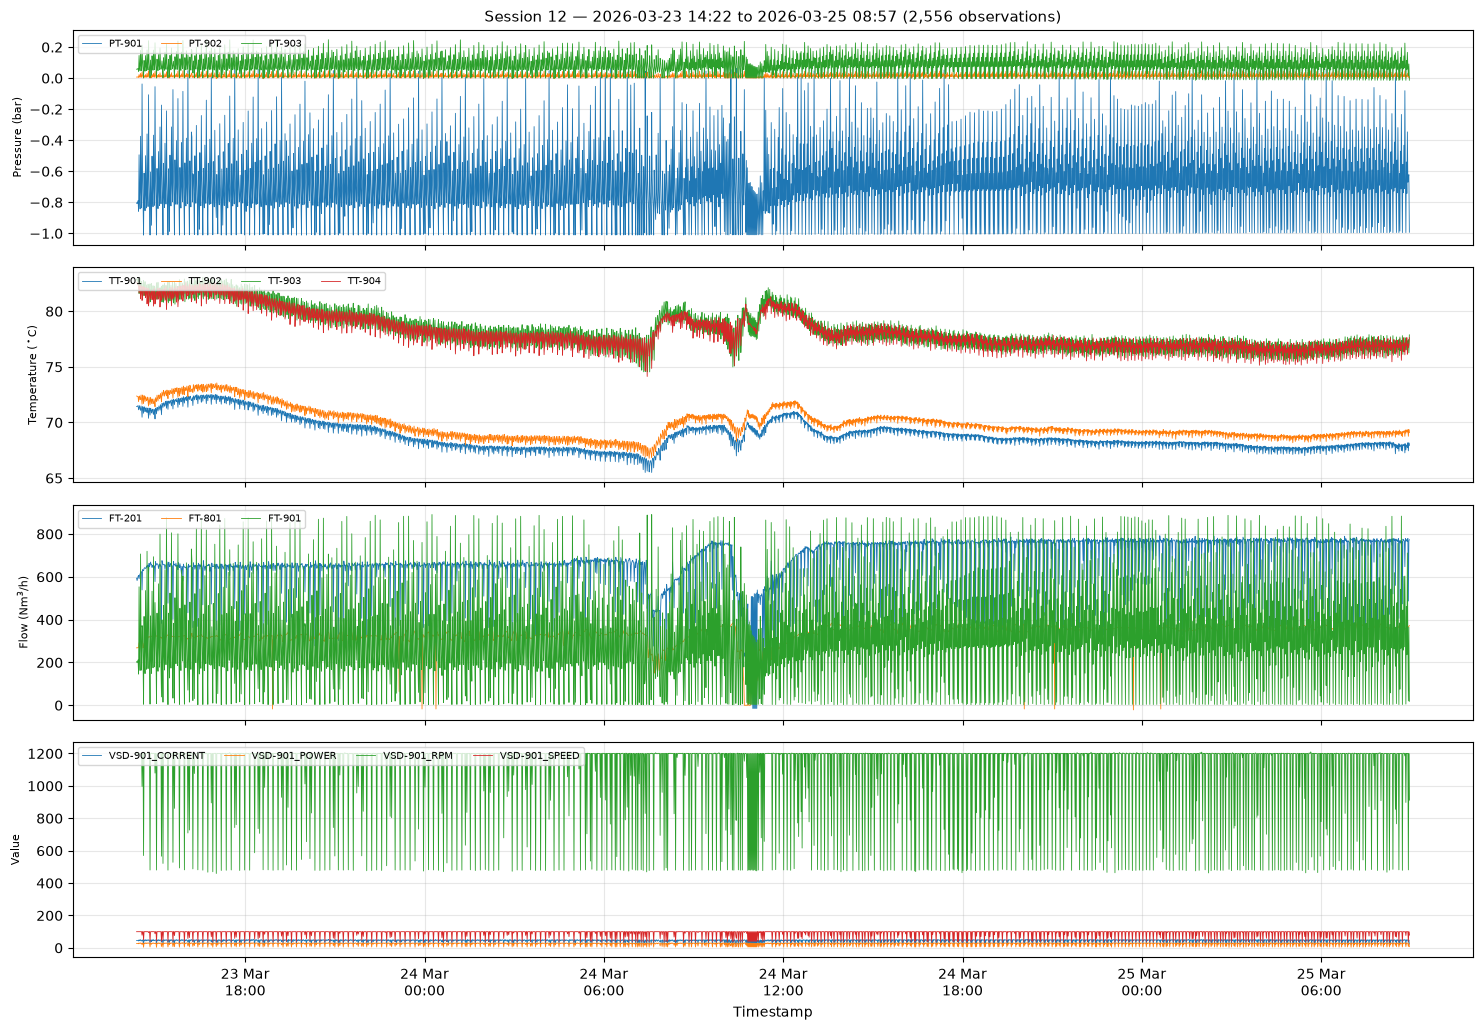

wrote ../imgs/eda_appendix_session_13.png


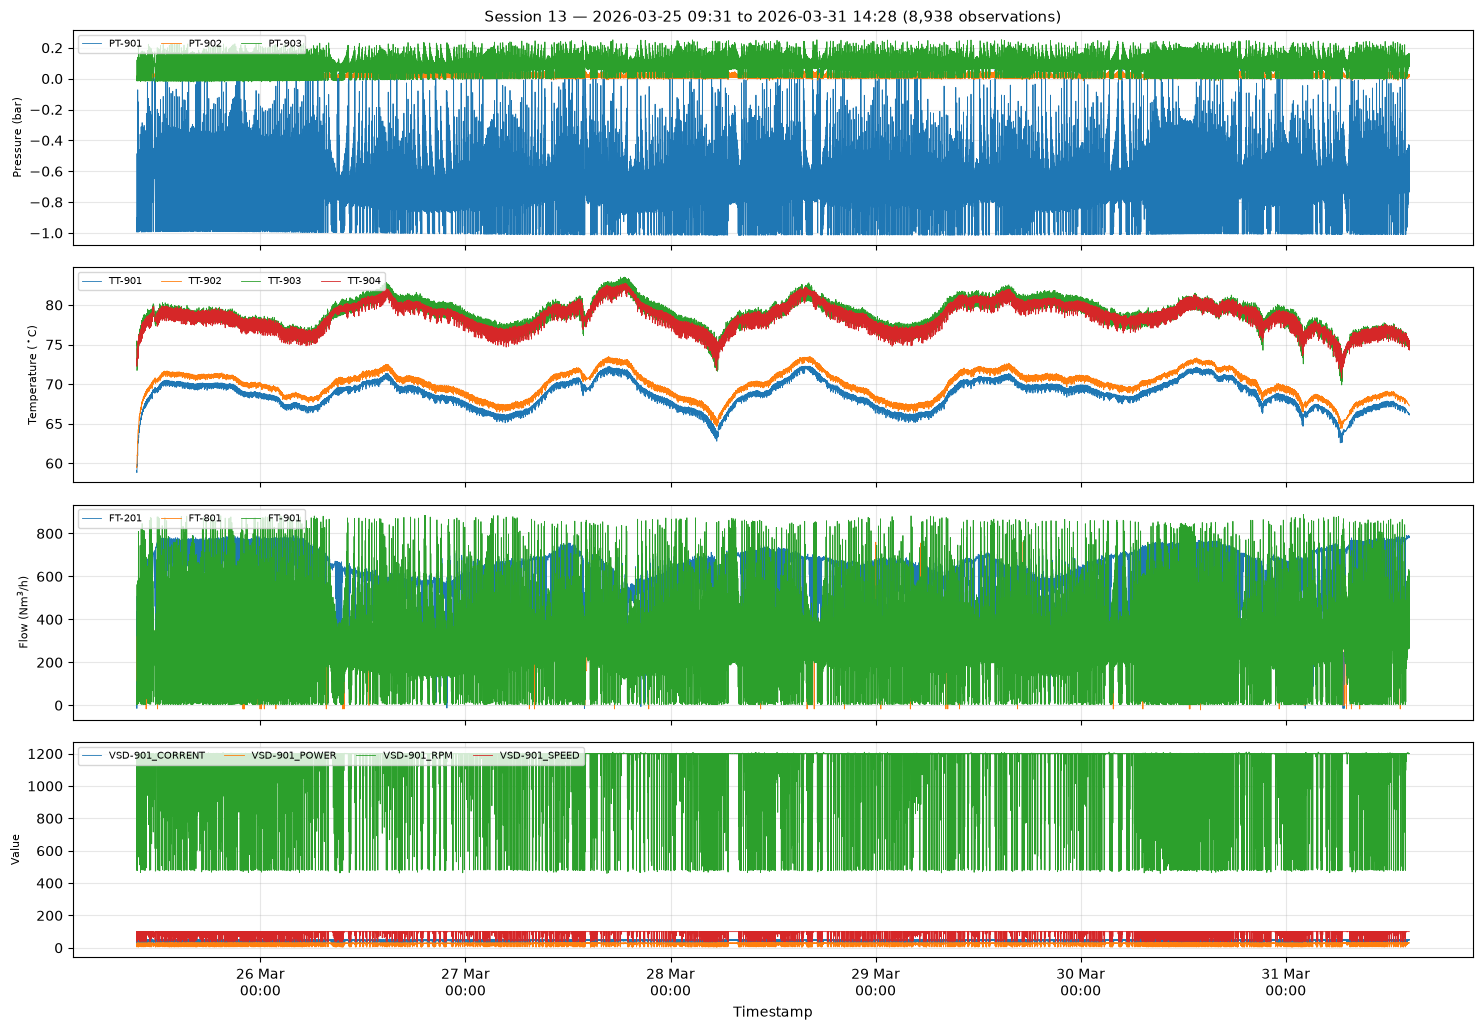

wrote ../imgs/eda_appendix_session_14.png


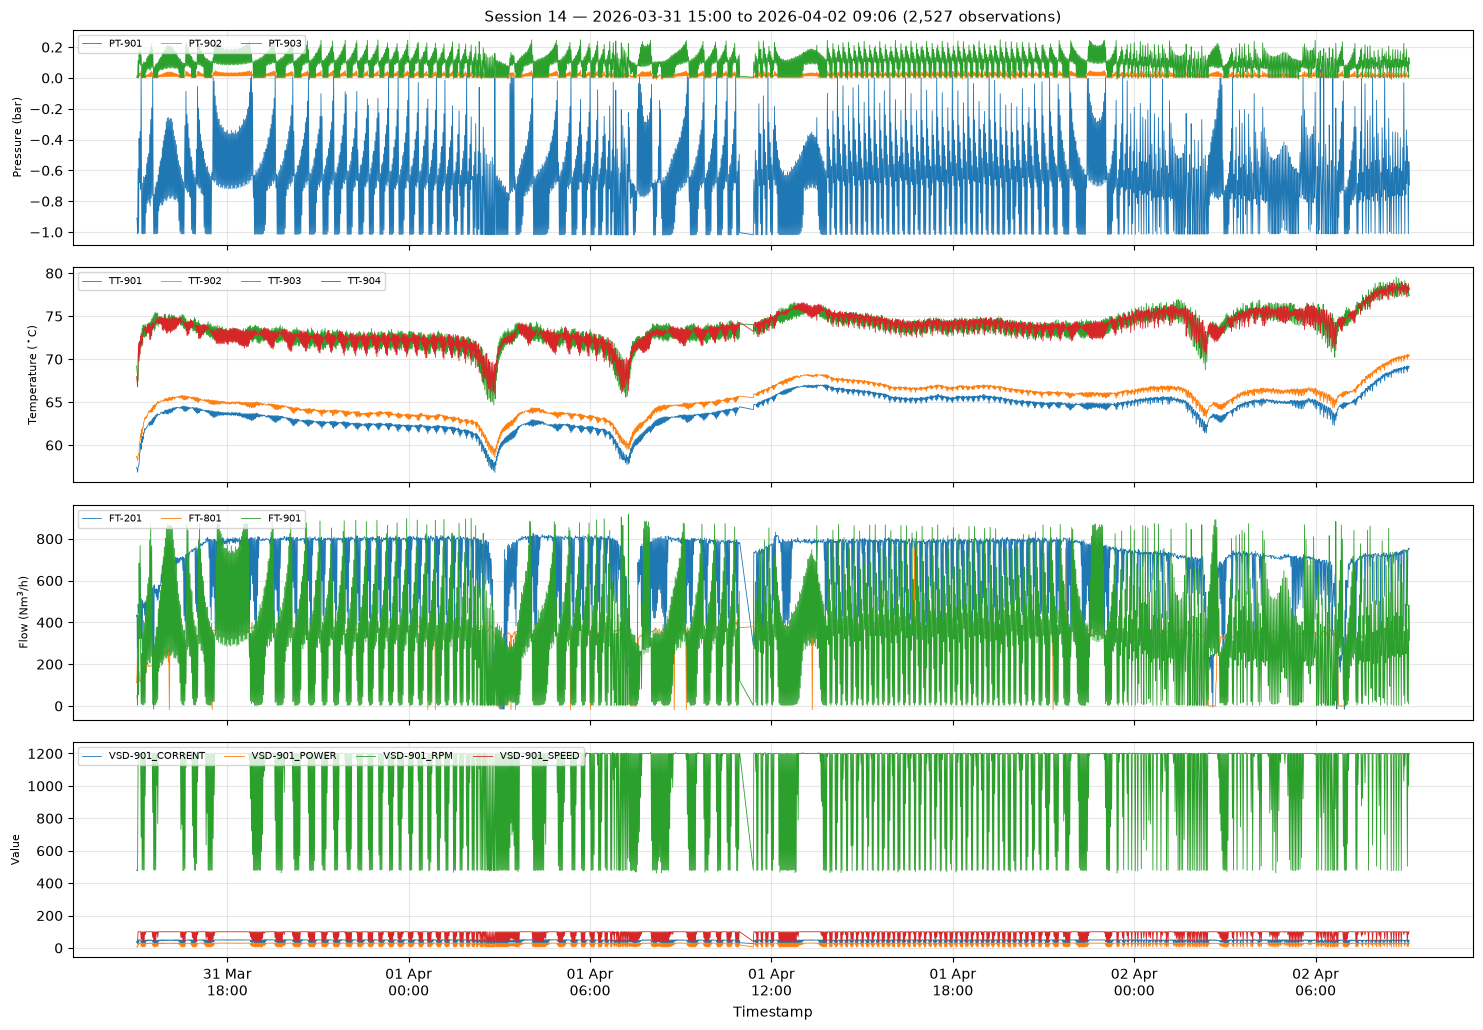

wrote ../imgs/eda_appendix_session_15.png


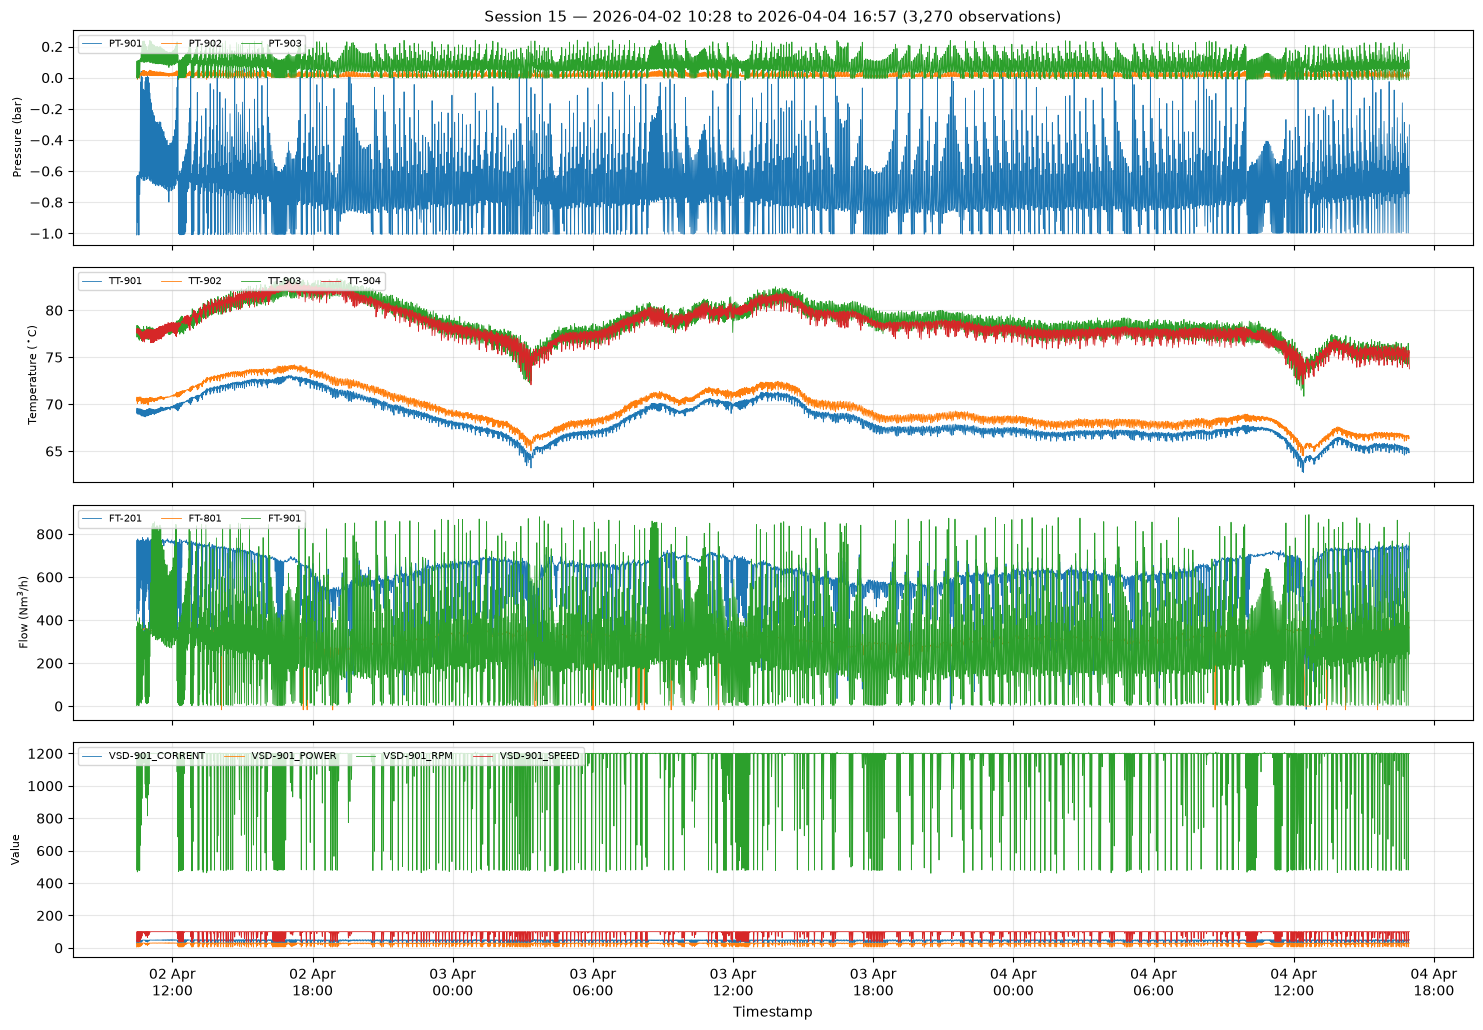

wrote ../imgs/eda_appendix_session_16.png


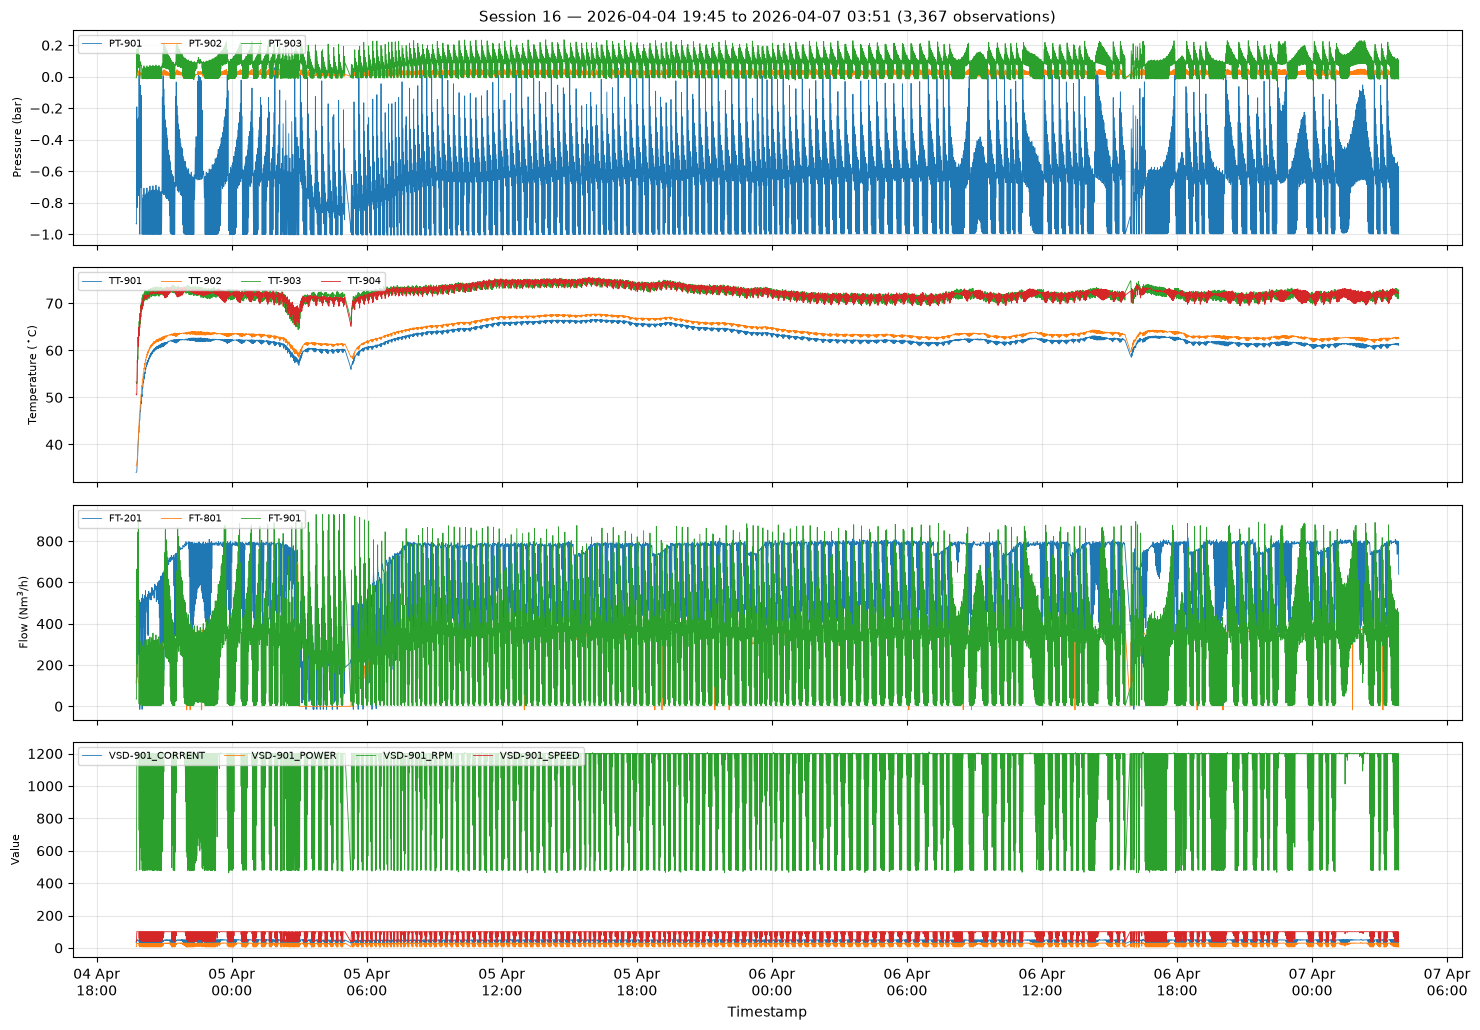

wrote ../imgs/eda_appendix_session_17.png


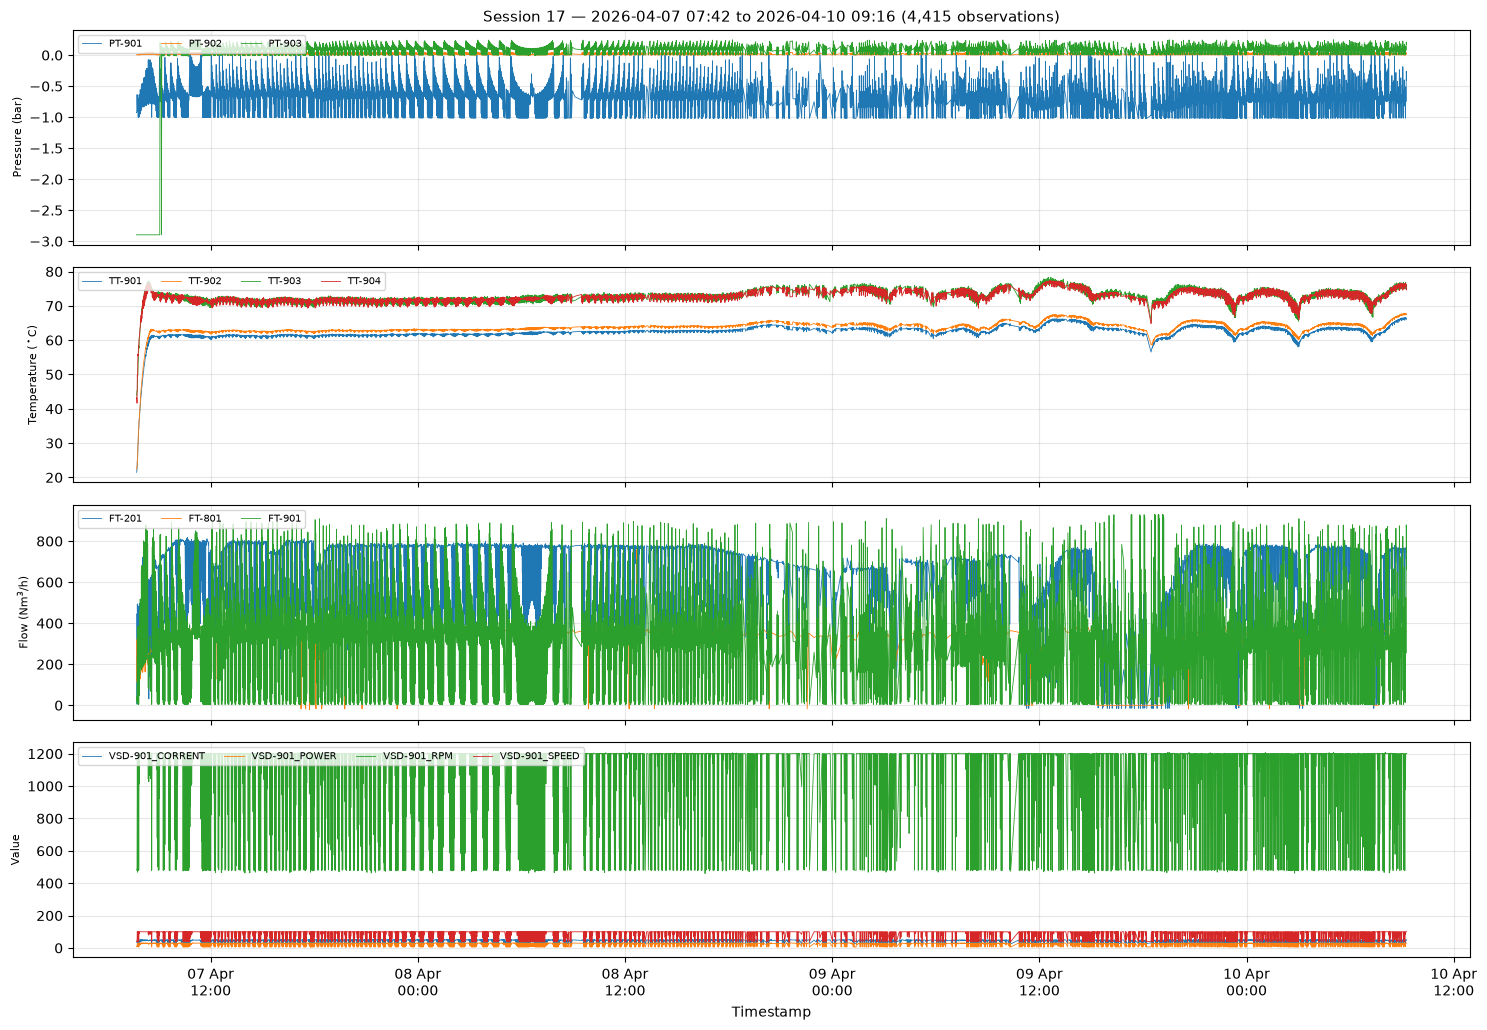

In [15]:
for session_id, df in sessions.items():
    groups = list(SENSOR_GROUPS.values())
    fig, axes = plt.subplots(len(groups), 1, figsize=(15, 2.6 * len(groups)), sharex=True)
    axes = np.atleast_1d(axes)

    for ax, (title, tags, ylabel) in zip(axes, groups):
        for tag in tags:
            if tag in df.columns:
                ax.plot(df.index, df[tag], linewidth=0.6, label=tag)
        ax.set_ylabel(ylabel, fontsize=8)
        ax.legend(fontsize=7, loc="upper left", ncol=len(tags))
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Timestamp")
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M"))
    axes[0].set_title(
        f"Session {session_id} — {df.index.min():%Y-%m-%d %H:%M} to "
        f"{df.index.max():%Y-%m-%d %H:%M} ({len(df):,} observations)", fontsize=11)
    fig.tight_layout()
    save(fig, f"eda_appendix_session_{session_id}.png")

## Per-session summary table

Feeds `Table~\ref{tab:ap1_session_stats}`.

In [16]:
lines = [
    r"% Auto-generated by eda.ipynb -- do not edit by hand",
    r"\begin{tabular}{crrrrr}",
    r"\hline",
    r"\textbf{Session} & \textbf{Obs.} & \textbf{PT-903 mean} & "
    r"\textbf{TT-901 mean} & \textbf{TT-904 mean} & \textbf{VSD current mean} \\",
    r"\hline",
]
total = 0
summary = []
for session_id, df in sessions.items():
    total += len(df)
    summary.append({
        "session": session_id, "obs": len(df),
        "PT-903": df["PT-903"].mean(), "TT-901": df["TT-901"].mean(),
        "TT-904": df["TT-904"].mean(), "VSD-901_CORRENT": df["VSD-901_CORRENT"].mean(),
    })
    lines.append(
        f"{session_id} & {len(df):,} & {df['PT-903'].mean():.3f} & "
        f"{df['TT-901'].mean():.2f} & {df['TT-904'].mean():.2f} & "
        f"{df['VSD-901_CORRENT'].mean():.2f} \\\\"
    )
lines += [
    r"\hline",
    rf"\textbf{{Total}} & \textbf{{{total:,}}} & & & & \\",
    r"\hline",
    r"\end{tabular}",
]
save_table("\n".join(lines) + "\n", "eda_session_stats.tex")

pd.DataFrame(summary).round(3)

wrote ../tables/eda_session_stats.tex


,session,obs,PT-903,TT-901,TT-904,VSD-901_CORRENT
0,1,2900,0.086,72.006,82.387,44.027
1,2,1799,0.088,73.513,83.748,44.533
2,3,4763,0.093,68.470,78.643,43.567
3,5,1606,0.089,65.491,76.278,44.355
4,8,1235,0.094,68.132,78.691,44.766
5,12,2556,0.090,68.816,78.122,44.100
6,13,8938,0.089,68.667,78.500,44.200
7,14,2527,0.099,63.917,73.550,42.992
8,15,3270,0.083,68.240,78.397,44.031
9,16,3367,0.082,62.499,72.166,41.993


---

All figures written to `../imgs/` and all tables to `../tables/`.
Re-run the whole notebook after any change to `data_cleaning.ipynb`.